# Projekt MAPB – Milestone 2: Eksploracja danych i analiza cech (Cotton Candy)

Notebook realizuje drugi kamień milowy projektu z przedmiotu **Modelowanie i analiza procesów biznesowych** dla zbioru danych *Cotton Candy* (log zdarzeń z maszyny do waty cukrowej).

## Zakres Milestone 2

**Analiza logu zdarzeń:**
1. Przygotowanie i czyszczenie logu zdarzeń – normalizacja timestampów, endpointów, usunięcie duplikatów
2. Wykrywanie wartości odstających – IQR, Isolation Forest
3. Redukcja wymiarowości – PCA, t-SNE, UMAP
4. Klasteryzacja – K-Means, DBSCAN + wizualizacje
5. Analiza relacji między zdarzeniami – macierz przejść (Directly-Follows), czasy przejść
6. Wzorce czasowe – godziny, dni tygodnia, sezonowość
7. Analiza częstości ścieżek – najczęstsze warianty procesu
8. Wykrywanie anomalii – Isolation Forest, LOF, konsensus metod

**Analiza danych sensorowych (główny fokus):**
9. Wczytanie danych sensorowych z plików `*-process.yaml` (strumienie `stream:datastream`)
10. Eksploracja i jakość danych sensorowych – statystyki per sensor, braki, wartości nienumeryczne
11. Analiza szeregów czasowych – trendy, rolling average, sezonowość sensorów
12. Korelacje i PCA – macierz korelacji między sensorami, redukcja wymiarowości
13. UMAP i klasteryzacja – K-Means + DBSCAN na cechach sensorowych, heatmapa profilu klastrów
14. Wykrywanie anomalii sensorowych – IQR per sensor, Isolation Forest, powiązanie z anomaliami logu


In [19]:
import os, re
from pathlib import Path
from collections import Counter, defaultdict
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score
import umap

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set(style="whitegrid")

# === ŚCIEŻKI ===
BASE_DIR = Path(r"/Users/kacperciesla/Documents/Studia/MiAPB")
DATA_DIR = BASE_DIR / "cotton-candy"

print("Katalog danych:", DATA_DIR)
print("Dostępne batche:", sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()))

Katalog danych: /Users/kacperciesla/Documents/Studia/MiAPB/cotton-candy
Dostępne batche: ['batch-0', 'batch-1', 'batch-10', 'batch-11', 'batch-12', 'batch-13', 'batch-14', 'batch-15', 'batch-16', 'batch-17', 'batch-18', 'batch-19', 'batch-2', 'batch-20', 'batch-21', 'batch-22', 'batch-23', 'batch-3', 'batch-4', 'batch-5', 'batch-6', 'batch-7', 'batch-8', 'batch-9']


## 1. Wczytanie logu zdarzeń

Wczytujemy **wszystkie** pliki `*.xes.yaml` ze wszystkich batchy do jednego DataFrame. Wykorzystujemy szybki parser strumieniowy (z Milestone 1), który wyciąga kluczowe atrybuty:
- `case_id` – UUID instancji CPEE (`cpee:instance`), fallback na `concept:instance`
- `activity` – nazwa aktywności (`concept:name`)
- `timestamp` – czas zdarzenia (`time:timestamp`)
- `resource` – znormalizowany endpoint (`concept:endpoint`)

In [20]:
INTEREST_KEYS = {
    "concept:instance", "cpee:instance", "concept:name",
    "time:timestamp", "concept:endpoint", "id:id",
    "cpee:activity", "lifecycle:transition", "cpee:lifecycle:transition",
}

def stream_events(file_path):
    """Generator: yields (event_dict, seq_no) for each event in a .xes.yaml file."""
    current = None
    seq = 0
    with file_path.open("r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n")
            if line == "---":
                if current is not None:
                    yield current, seq
                current = None
                continue
            if line == "event:":
                current = {}
                seq += 1
                continue
            if current is None:
                continue
            if line.startswith("  ") and not line.startswith("    "):
                stripped = line.strip()
                if ": " in stripped:
                    key, value = stripped.split(": ", 1)
                elif stripped.endswith(":"):
                    key, value = stripped[:-1], ""
                else:
                    continue
                if key in INTEREST_KEYS and key not in current:
                    current[key] = value.strip("'\"")
    if current is not None:
        yield current, seq

def normalize_resource(endpoint):
    """Normalizuje endpoint URL do nazwy hosta (resource proxy)."""
    if endpoint is None or pd.isna(endpoint):
        return None

    if not isinstance(endpoint, str):
        endpoint = str(endpoint)

    endpoint = endpoint.strip()
    if endpoint == "":
        return None

    endpoint = endpoint.replace("https-get://", "https://").replace("https-post://", "https://")
    parsed = urlparse(endpoint)
    return parsed.netloc if parsed.netloc else endpoint

# === Wczytanie wszystkich eventów ===
all_xes_files = sorted(DATA_DIR.glob("batch-*/*.xes.yaml"))
print(f"Liczba plików *.xes.yaml: {len(all_xes_files)}")

rows = []
for i, path in enumerate(all_xes_files, start=1):
    batch_name = path.parent.name
    file_id = str(path.relative_to(DATA_DIR)).replace("\\", "/")

    for event, seq in stream_events(path):
        rows.append({
            "batch": batch_name,
            "file": file_id,
            "case_id": event.get("cpee:instance") or event.get("concept:instance") or file_id,
            "concept_instance": event.get("concept:instance"),
            "activity": event.get("concept:name") or event.get("id:id") or event.get("cpee:activity"),
            "timestamp_raw": event.get("time:timestamp"),
            "endpoint": event.get("concept:endpoint"),
            "lifecycle": event.get("lifecycle:transition"),
            "cpee_lifecycle": event.get("cpee:lifecycle:transition"),
            "seq": seq,
        })
    if i % 200 == 0:
        print(f"  Przetworzono: {i}/{len(all_xes_files)} plików ({len(rows)} eventów)")

df = pd.DataFrame(rows)
print(f"\nWczytano {len(df)} zdarzeń z {df['case_id'].nunique()} przypadków")
print(f"Rozmiar DataFrame: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Liczba plików *.xes.yaml: 1294
  Przetworzono: 200/1294 plików (70113 eventów)
  Przetworzono: 400/1294 plików (149549 eventów)
  Przetworzono: 600/1294 plików (258503 eventów)
  Przetworzono: 800/1294 plików (347549 eventów)
  Przetworzono: 1000/1294 plików (438885 eventów)
  Przetworzono: 1200/1294 plików (526361 eventów)

Wczytano 564185 zdarzeń z 1244 przypadków
Rozmiar DataFrame: 366.7 MB


,batch,file,case_id,concept_instance,activity,timestamp_raw,endpoint,lifecycle,cpee_lifecycle,seq
0,batch-0,batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.x...,028e282d-26a3-4ae8-909e-a033e6794cc8,61168,external,2025-07-28T01:44:28.602373+02:00,NaN,unknown,state/change,1
1,batch-0,batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.x...,028e282d-26a3-4ae8-909e-a033e6794cc8,61168,external,2025-07-28T01:44:28.608118+02:00,NaN,unknown,endpoints/change,2
2,batch-0,batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.x...,028e282d-26a3-4ae8-909e-a033e6794cc8,61168,external,2025-07-28T01:44:28.605931+02:00,NaN,unknown,dataelements/change,3
3,batch-0,batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.x...,028e282d-26a3-4ae8-909e-a033e6794cc8,61168,external,2025-07-28T01:44:28.610887+02:00,NaN,unknown,attributes/change,4
4,batch-0,batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.x...,028e282d-26a3-4ae8-909e-a033e6794cc8,61168,external,2025-07-28T01:44:28.616227+02:00,NaN,unknown,description/change,5


## 2. Czyszczenie i normalizacja danych

- Parsowanie timestampów do UTC (`pd.to_datetime`)
- Normalizacja endpointów → pole `resource` (hostname)
- Oczyszczenie nazw aktywności (trimming białych znaków)
- Usunięcie duplikatów (na podstawie kluczowych kolumn)
- Usunięcie zdarzeń bez timestampa (niemożliwe do analizy czasowej)
- Sortowanie chronologiczne wewnątrz każdego case

In [21]:
# 2.1 Parsowanie timestampów do UTC
df["timestamp"] = pd.to_datetime(df["timestamp_raw"], errors="coerce", utc=True)

ts_parsed = df["timestamp"].notna().sum()
ts_total = df["timestamp_raw"].notna().sum()
print(f"Sparsowane timestampy: {ts_parsed}/{ts_total} ({ts_parsed/max(ts_total,1)*100:.1f}%)")

# 2.2 Normalizacja endpointów -> resource (hostname)
df["resource"] = df["endpoint"].apply(normalize_resource)

# 2.3 Oczyszczenie nazw aktywności
df["activity_clean"] = df["activity"].str.strip()

# 2.4 Usunięcie dokładnych duplikatów
before = len(df)
df = df.drop_duplicates(
    subset=["case_id", "activity", "timestamp_raw", "endpoint", "lifecycle", "cpee_lifecycle"]
)
after = len(df)
print(f"Usunięto duplikatów: {before - after}")

# 2.5 Sortowanie chronologiczne
df = df.sort_values(["case_id", "timestamp"]).reset_index(drop=True)

# 2.6 Podsumowanie braków
print(f"\nPo czyszczeniu: {len(df)} zdarzeń, {df['case_id'].nunique()} przypadków")
print(f"\nBraki danych:")
for col in ["case_id", "activity_clean", "timestamp", "resource"]:
    n_miss = df[col].isna().sum()
    print(f"  {col}: {n_miss} ({n_miss/len(df)*100:.1f}%)")

# 2.7 Usunięcie zdarzeń bez timestampa
df = df.dropna(subset=["timestamp"]).reset_index(drop=True)
print(f"\nPo usunięciu zdarzeń bez timestampa: {len(df)} zdarzeń, {df['case_id'].nunique()} cases")

# Podgląd
df[["case_id", "activity_clean", "timestamp", "resource", "batch"]].head(10)

Sparsowane timestampy: 483714/483714 (100.0%)
Usunięto duplikatów: 99812

Po czyszczeniu: 464373 zdarzeń, 1244 przypadków

Braki danych:
  case_id: 0 (0.0%)
  activity_clean: 0 (0.0%)
  timestamp: 871 (0.2%)
  resource: 115153 (24.8%)

Po usunięciu zdarzeń bez timestampa: 463502 zdarzeń, 1244 cases


,case_id,activity_clean,timestamp,resource,batch
0,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:11.105661+00:00,NaN,batch-6
1,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:11.108089+00:00,NaN,batch-6
2,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:11.110489+00:00,NaN,batch-6
3,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:11.112730+00:00,NaN,batch-6
4,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:11.121995+00:00,NaN,batch-6
5,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:12.104285+00:00,NaN,batch-6
6,002252ca-78eb-47cb-b28f-59fc371e4211,Initialize Count,2025-08-07 12:04:12.126444+00:00,NaN,batch-6
7,002252ca-78eb-47cb-b28f-59fc371e4211,Initialize Count,2025-08-07 12:04:12.127820+00:00,NaN,batch-6
8,002252ca-78eb-47cb-b28f-59fc371e4211,Move down,2025-08-07 12:04:12.174519+00:00,lab.bpm.in.tum.de,batch-6
9,002252ca-78eb-47cb-b28f-59fc371e4211,Move down,2025-08-07 12:04:16.268280+00:00,lab.bpm.in.tum.de,batch-6


## 3. Inżynieria cech i wykrywanie wartości odstających (outlierów)

Budujemy **macierz cech na poziomie przypadku** (case-level features):
- liczba zdarzeń, unikatowych aktywności, unikatowych zasobów
- czas trwania case, średni czas między zdarzeniami
- cechy temporalne (godzina startu, dzień tygodnia)
- częstości top aktywności (frequency encoding)

Następnie identyfikujemy outlierów dwoma metodami:
- **IQR** (Interquartile Range) – klasyczna metoda statystyczna
- **Isolation Forest** – algorytm uczenia maszynowego

In [22]:
# === 3.1 Macierz cech na poziomie przypadku ===

case_stats = df.groupby("case_id").agg(
    n_events=("activity_clean", "size"),
    n_unique_activities=("activity_clean", "nunique"),
    n_unique_resources=("resource", "nunique"),
    start_time=("timestamp", "min"),
    end_time=("timestamp", "max"),
    batch=("batch", "first"),
).reset_index()

# Czas trwania case [s]
case_stats["duration_sec"] = (
    case_stats["end_time"] - case_stats["start_time"]
).dt.total_seconds()

# Średni czas między zdarzeniami [s]
avg_gap = (
    df.groupby("case_id")["timestamp"]
    .apply(lambda x: x.diff().dt.total_seconds().mean() if len(x) > 1 else 0)
    .rename("avg_gap_sec")
)
case_stats = case_stats.merge(avg_gap, on="case_id", how="left")
case_stats["avg_gap_sec"] = case_stats["avg_gap_sec"].fillna(0)

# Cechy temporalne
case_stats["start_hour"] = case_stats["start_time"].dt.hour
case_stats["start_dow"] = case_stats["start_time"].dt.dayofweek  # 0=Mon, 6=Sun

# Frequency encoding: top 15 aktywności jako osobne kolumny
# Uwaga: skracanie nazw może powodować kolizje, więc pilnujemy unikalności nazw kolumn.
top_activities = df["activity_clean"].value_counts().head(15).index.tolist()
used_feature_names = set(case_stats.columns)

for i, act in enumerate(top_activities, start=1):
    base_name = re.sub(r"[^a-zA-Z0-9]", "_", str(act)).strip("_")
    if not base_name:
        base_name = f"activity_{i}"

    # Dodajemy indeks pozycji, aby uniknąć kolizji po obcięciu długości nazwy.
    col_name = f"act_{i:02d}_{base_name[:24]}"

    # Dodatkowe zabezpieczenie na wypadek rzadkich kolizji.
    suffix = 1
    unique_name = col_name
    while unique_name in used_feature_names:
        suffix += 1
        unique_name = f"{col_name}_{suffix}"
    col_name = unique_name
    used_feature_names.add(col_name)

    act_counts = (
        df[df["activity_clean"] == act]
        .groupby("case_id")
        .size()
        .rename(col_name)
    )

    case_stats = case_stats.merge(act_counts, on="case_id", how="left")
    case_stats[col_name] = case_stats[col_name].fillna(0).astype(int)

print(f"Macierz cech: {case_stats.shape[0]} cases × {case_stats.shape[1]} kolumn")
print(f"\nStatystyki kluczowych cech:")
print(case_stats[["n_events", "n_unique_activities", "duration_sec", "avg_gap_sec"]].describe())

# === 3.2 Standaryzacja cech numerycznych ===
numeric_cols = ["n_events", "duration_sec", "n_unique_activities", "avg_gap_sec", "n_unique_resources"]
feature_cols = numeric_cols + [c for c in case_stats.columns if c.startswith("act_")]
X_features = case_stats[feature_cols].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
print(f"\nZeskalowana macierz cech: {X_scaled.shape}")

Macierz cech: 1244 cases × 26 kolumn

Statystyki kluczowych cech:
           n_events  n_unique_activities   duration_sec  avg_gap_sec
count   1244.000000          1244.000000    1244.000000  1244.000000
mean     372.590032             8.031350     385.362545     2.550818
std     1158.427617             7.399407    5923.378721    35.636584
min       15.000000             4.000000       3.726642     0.162403
25%       27.000000             4.000000      19.465343     0.349526
50%       42.000000             5.000000      32.381377     0.506104
75%       81.000000             7.000000      83.757225     1.047164
max    26192.000000            34.000000  205121.405661  1235.671118

Zeskalowana macierz cech: (1244, 20)


Outliery (IQR): 304 / 1244 (24.4%)
  n_events: 194 outlierów
  duration_sec: 213 outlierów
  n_unique_activities: 184 outlierów
  avg_gap_sec: 119 outlierów

Outliery (Isolation Forest, 5%): 63 / 1244


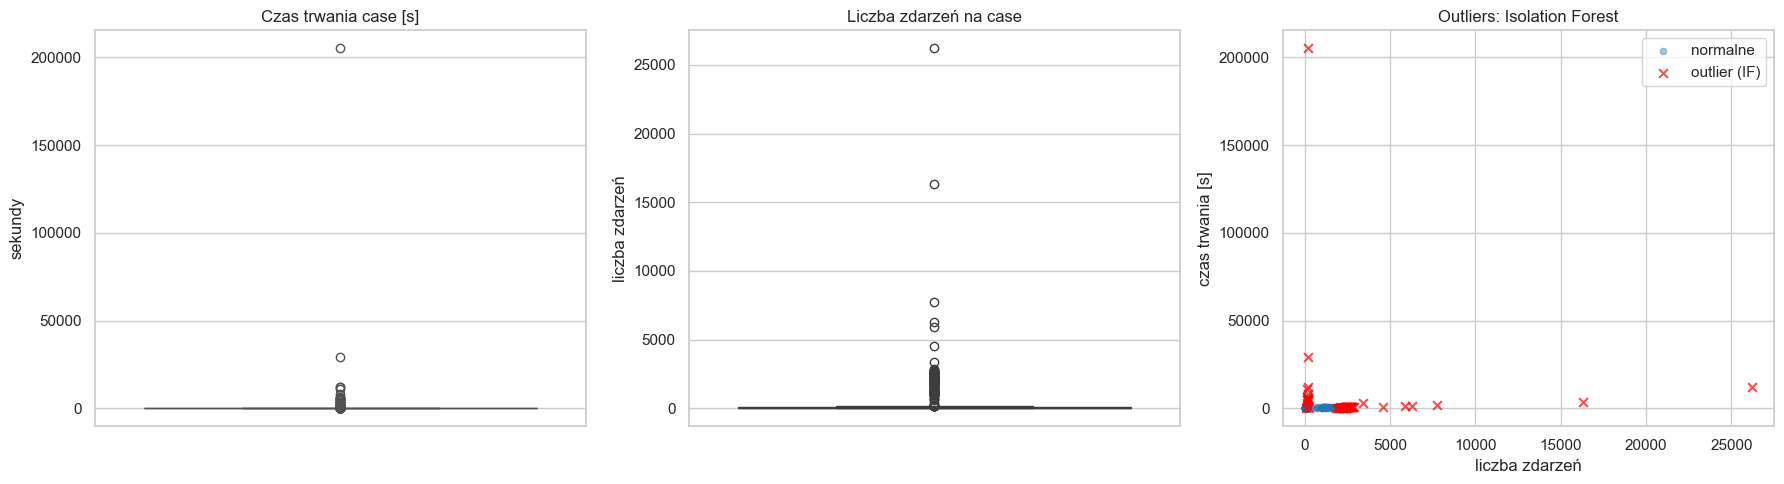


Outliery wspólne (IQR ∩ IF): 62


In [23]:
# === 3.3 Wykrywanie outlierów ===

# --- Metoda IQR ---
iqr_flags = pd.DataFrame(index=case_stats.index)
for col in numeric_cols:
    Q1 = case_stats[col].quantile(0.25)
    Q3 = case_stats[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_flags[col] = (case_stats[col] < Q1 - 1.5 * IQR) | (case_stats[col] > Q3 + 1.5 * IQR)

case_stats["iqr_outlier"] = iqr_flags.any(axis=1)
print(f"Outliery (IQR): {case_stats['iqr_outlier'].sum()} / {len(case_stats)} "
      f"({case_stats['iqr_outlier'].mean()*100:.1f}%)")

# Szczegóły: ile outlierów per cecha
for col in numeric_cols:
    n = iqr_flags[col].sum()
    if n > 0:
        print(f"  {col}: {n} outlierów")

# --- Isolation Forest ---
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
case_stats["iso_outlier"] = iso_forest.fit_predict(X_scaled) == -1
print(f"\nOutliery (Isolation Forest, 5%): {case_stats['iso_outlier'].sum()} / {len(case_stats)}")

# === 3.4 Wizualizacja outlierów ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=case_stats["duration_sec"], ax=axes[0], color="#ff7f0e")
axes[0].set_title("Czas trwania case [s]")
axes[0].set_ylabel("sekundy")

sns.boxplot(y=case_stats["n_events"], ax=axes[1], color="#2ca02c")
axes[1].set_title("Liczba zdarzeń na case")
axes[1].set_ylabel("liczba zdarzeń")

# Scatter z oznaczeniem outlierów Isolation Forest
normal_mask = ~case_stats["iso_outlier"]
axes[2].scatter(
    case_stats.loc[normal_mask, "n_events"],
    case_stats.loc[normal_mask, "duration_sec"],
    alpha=0.4, s=20, label="normalne", c="#1f77b4"
)
axes[2].scatter(
    case_stats.loc[~normal_mask, "n_events"],
    case_stats.loc[~normal_mask, "duration_sec"],
    alpha=0.7, s=40, label="outlier (IF)", c="red", marker="x"
)
axes[2].set_xlabel("liczba zdarzeń")
axes[2].set_ylabel("czas trwania [s]")
axes[2].set_title("Outliers: Isolation Forest")
axes[2].legend()

plt.tight_layout()
plt.show()

# Wspólne outliery obu metod
both = (case_stats["iqr_outlier"] & case_stats["iso_outlier"]).sum()
print(f"\nOutliery wspólne (IQR ∩ IF): {both}")

## 4. Redukcja wymiarowości (PCA / t-SNE / UMAP)

Stosujemy trzy metody redukcji wymiarowości na macierzy cech case-level:
- **PCA** – liniowa redukcja, analiza wariancji wyjaśnionej
- **t-SNE** – nieliniowa, dobra do wizualizacji lokalnych struktur
- **UMAP** – nieliniowa, zachowuje strukturę globalną i lokalną

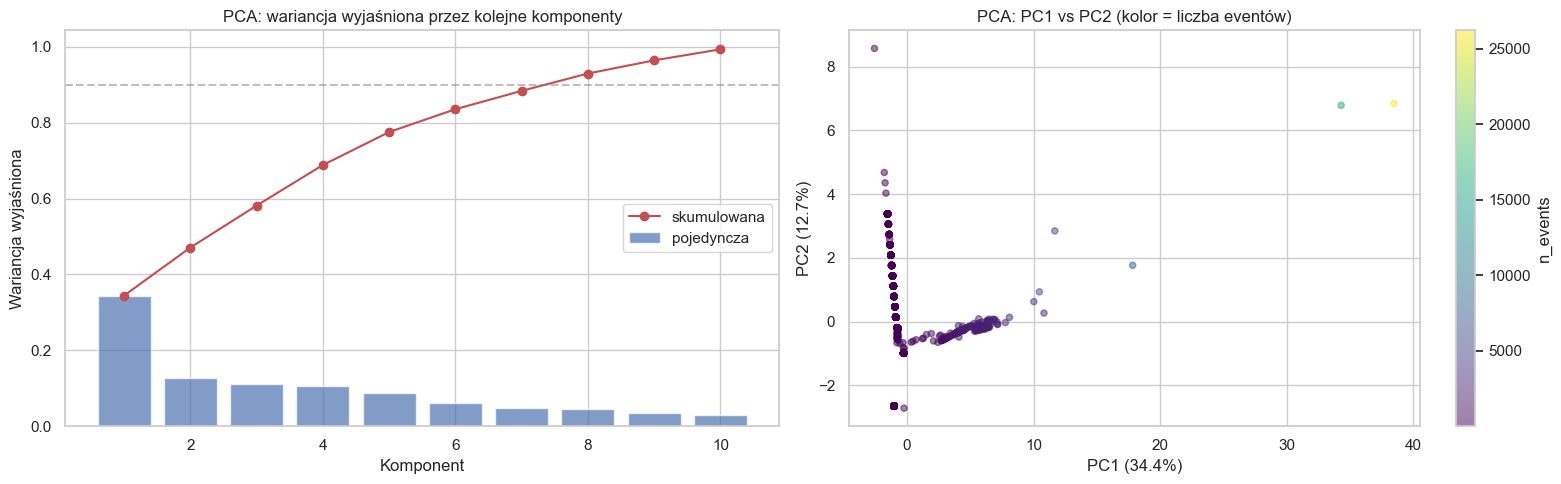

Komponenty potrzebne do 90% wariancji: 8
Wariancja PC1+PC2: 47.1%


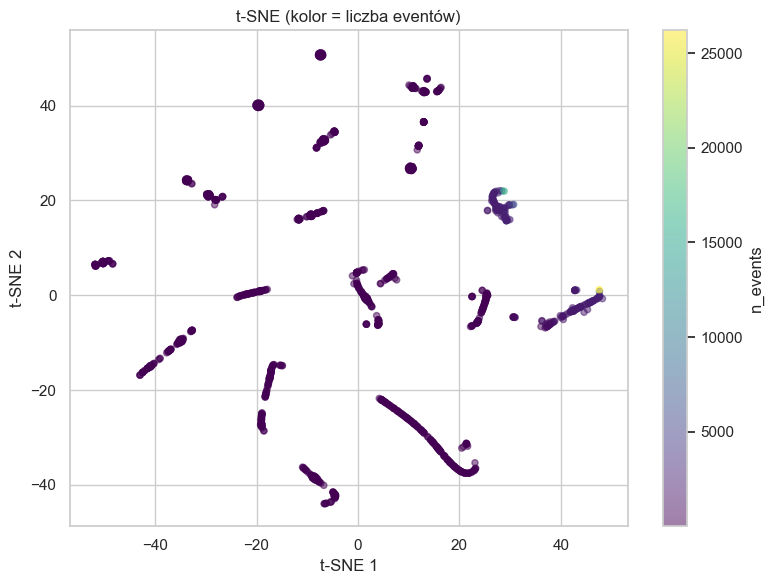

/opt/miniconda3/envs/base1/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


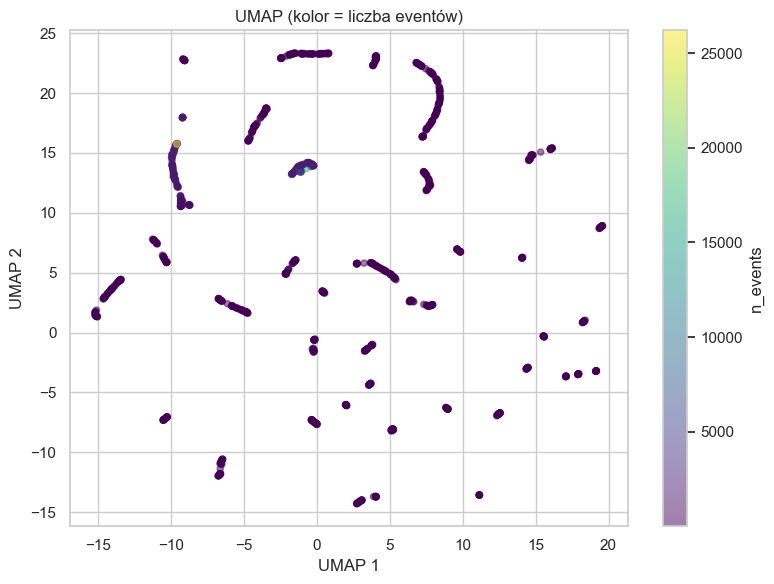

In [24]:
# === 4.1 PCA ===
n_components_pca = min(10, X_scaled.shape[1])
pca = PCA(n_components=n_components_pca, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Wariancja wyjaśniona
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, alpha=0.7, label="pojedyncza")
axes[0].plot(range(1, len(cumvar) + 1), cumvar, 'ro-', label="skumulowana")
axes[0].set_xlabel("Komponent")
axes[0].set_ylabel("Wariancja wyjaśniona")
axes[0].set_title("PCA: wariancja wyjaśniona przez kolejne komponenty")
axes[0].legend()
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label="90%")

# Scatter PC1 vs PC2
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=case_stats["n_events"], cmap="viridis", alpha=0.5, s=20)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("PCA: PC1 vs PC2 (kolor = liczba eventów)")
plt.colorbar(sc, ax=axes[1], label="n_events")

plt.tight_layout()
plt.show()

n_90 = int(np.argmax(cumvar >= 0.9)) + 1
print(f"Komponenty potrzebne do 90% wariancji: {n_90}")
print(f"Wariancja PC1+PC2: {cumvar[1]*100:.1f}%")

# === 4.2 t-SNE ===
perplexity = min(30, max(5, len(X_scaled) // 5))
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                 c=case_stats["n_events"], cmap="viridis", alpha=0.5, s=20)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE (kolor = liczba eventów)")
plt.colorbar(sc, label="n_events")
plt.tight_layout()
plt.show()

# === 4.3 UMAP ===
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                 c=case_stats["n_events"], cmap="viridis", alpha=0.5, s=20)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP (kolor = liczba eventów)")
plt.colorbar(sc, label="n_events")
plt.tight_layout()
plt.show()

## 5. Klasteryzacja

Stosujemy dwa algorytmy klasteryzacji na zestandaryzowanej macierzy cech:
- **K-Means** – z doborem optymalnego *k* (Elbow + Silhouette)
- **DBSCAN** – wykrywanie klastrów o dowolnym kształcie + identyfikacja szumu

Wyniki wizualizujemy na rzutach UMAP.

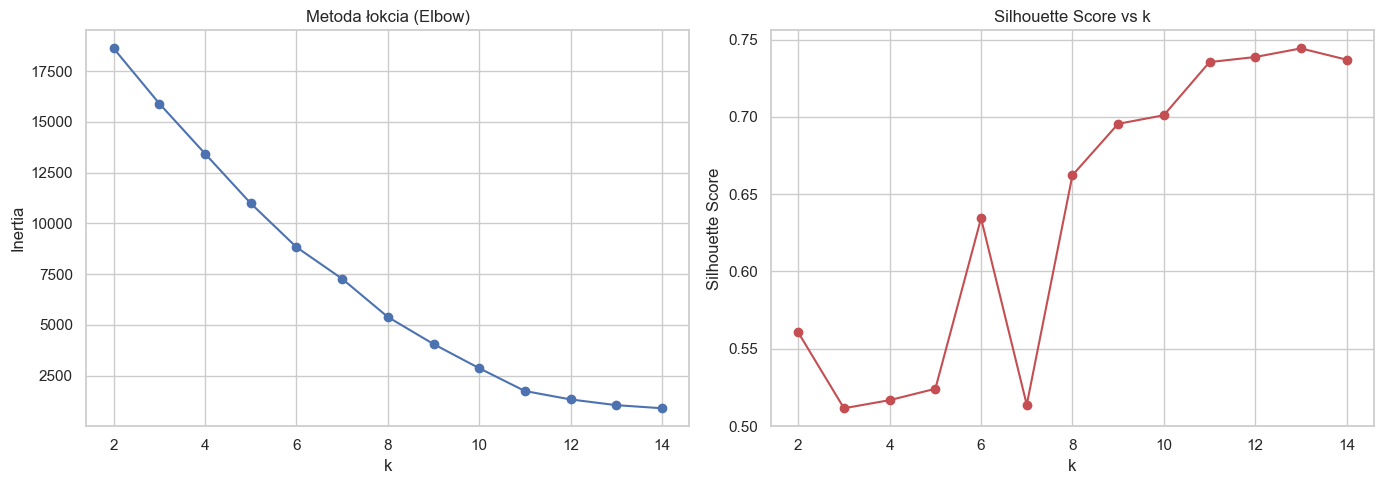

Najlepsze k (max silhouette): 13 (score=0.744)
DBSCAN: 8 klastrów, 21 punktów szumu


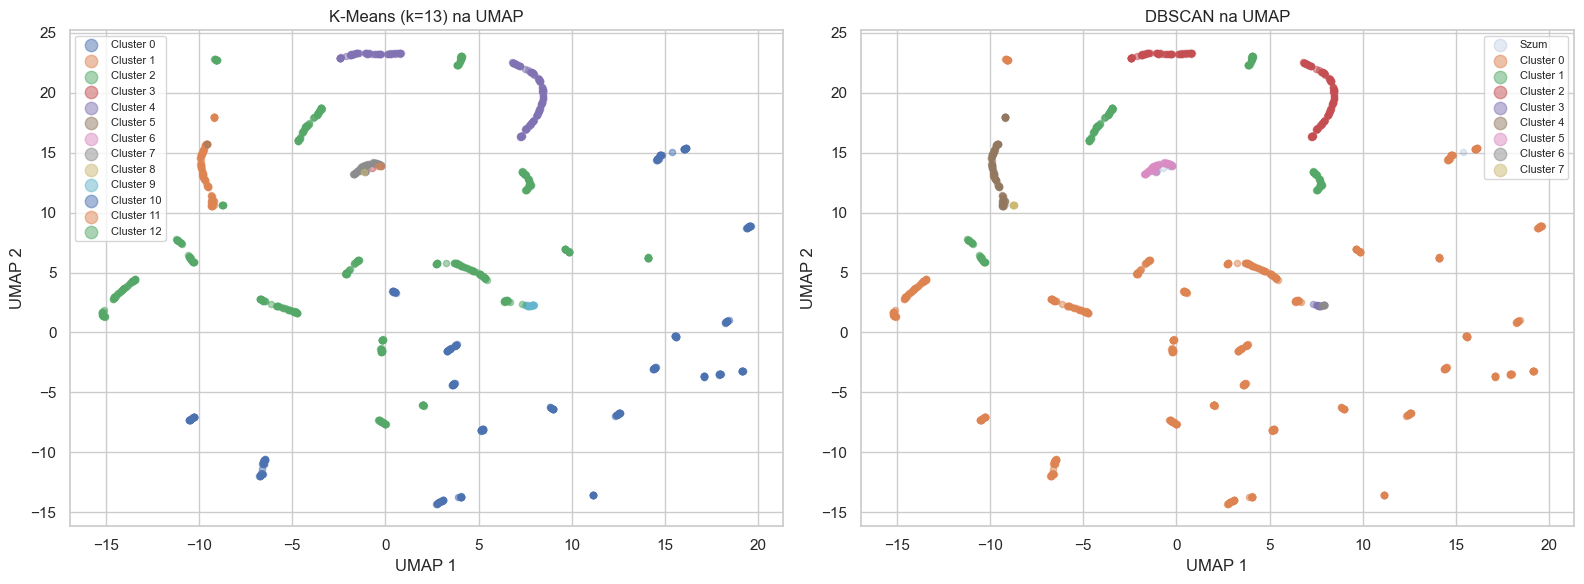


Profil klastrów (K-Means):
                n_events                n_unique_activities              duration_sec                  avg_gap_sec                n_unique_resources         \
                    mean   median count                mean median count         mean     median count        mean   median count               mean median   
kmeans_cluster                                                                                                                                                
0                  50.70     45.0   223                4.00    4.0   223        22.65      21.43   223        0.45     0.45   223               1.00    1.0   
1                1815.18   1877.0   106               22.99   23.0   106       486.03     466.28   106        0.29     0.23   106               2.00    2.0   
2                  42.00     42.0   170                7.00    7.0   170        32.27      33.48   170        0.79     0.82   170               1.00    1.0   
3               16

In [25]:
# === 5.1 Dobór optymalnego k (Elbow + Silhouette) ===
K_range = range(2, 15)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Metoda łokcia (Elbow)")

axes[1].plot(list(K_range), silhouettes, 'ro-')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print(f"Najlepsze k (max silhouette): {best_k} (score={max(silhouettes):.3f})")

# === 5.2 K-Means z optymalnym k ===
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
case_stats["kmeans_cluster"] = km_best.fit_predict(X_scaled)

# === 5.3 DBSCAN ===
dbscan = DBSCAN(eps=1.5, min_samples=5)
case_stats["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_dbscan_clusters = len(set(case_stats["dbscan_cluster"])) - (1 if -1 in case_stats["dbscan_cluster"].values else 0)
n_dbscan_noise = (case_stats["dbscan_cluster"] == -1).sum()
print(f"DBSCAN: {n_dbscan_clusters} klastrów, {n_dbscan_noise} punktów szumu")

# === 5.4 Wizualizacja klastrów na UMAP ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cl in sorted(case_stats["kmeans_cluster"].unique()):
    mask = case_stats["kmeans_cluster"] == cl
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1], alpha=0.5, s=20, label=f"Cluster {cl}")
axes[0].set_title(f"K-Means (k={best_k}) na UMAP")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].legend(markerscale=2, fontsize=8)

for cl in sorted(case_stats["dbscan_cluster"].unique()):
    mask = case_stats["dbscan_cluster"] == cl
    label = f"Cluster {cl}" if cl != -1 else "Szum"
    alpha = 0.5 if cl != -1 else 0.15
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], alpha=alpha, s=20, label=label)
axes[1].set_title("DBSCAN na UMAP")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

# === 5.5 Profil klastrów (K-Means) ===
profile_cols = ["n_events", "n_unique_activities", "duration_sec", "avg_gap_sec", "n_unique_resources"]
cluster_profile = case_stats.groupby("kmeans_cluster")[profile_cols].agg(["mean", "median", "count"])
print("\nProfil klastrów (K-Means):")
print(cluster_profile.round(2))

## 6. Analiza relacji między zdarzeniami

- **Macierz przejść (Directly-Follows)** – ile razy aktywność A była bezpośrednio następowana przez B
- **Top przejścia** – najczęstsze pary kolejnych aktywności
- **Czas przejścia** – rozkład czasu między kolejnymi zdarzeniami per typ przejścia

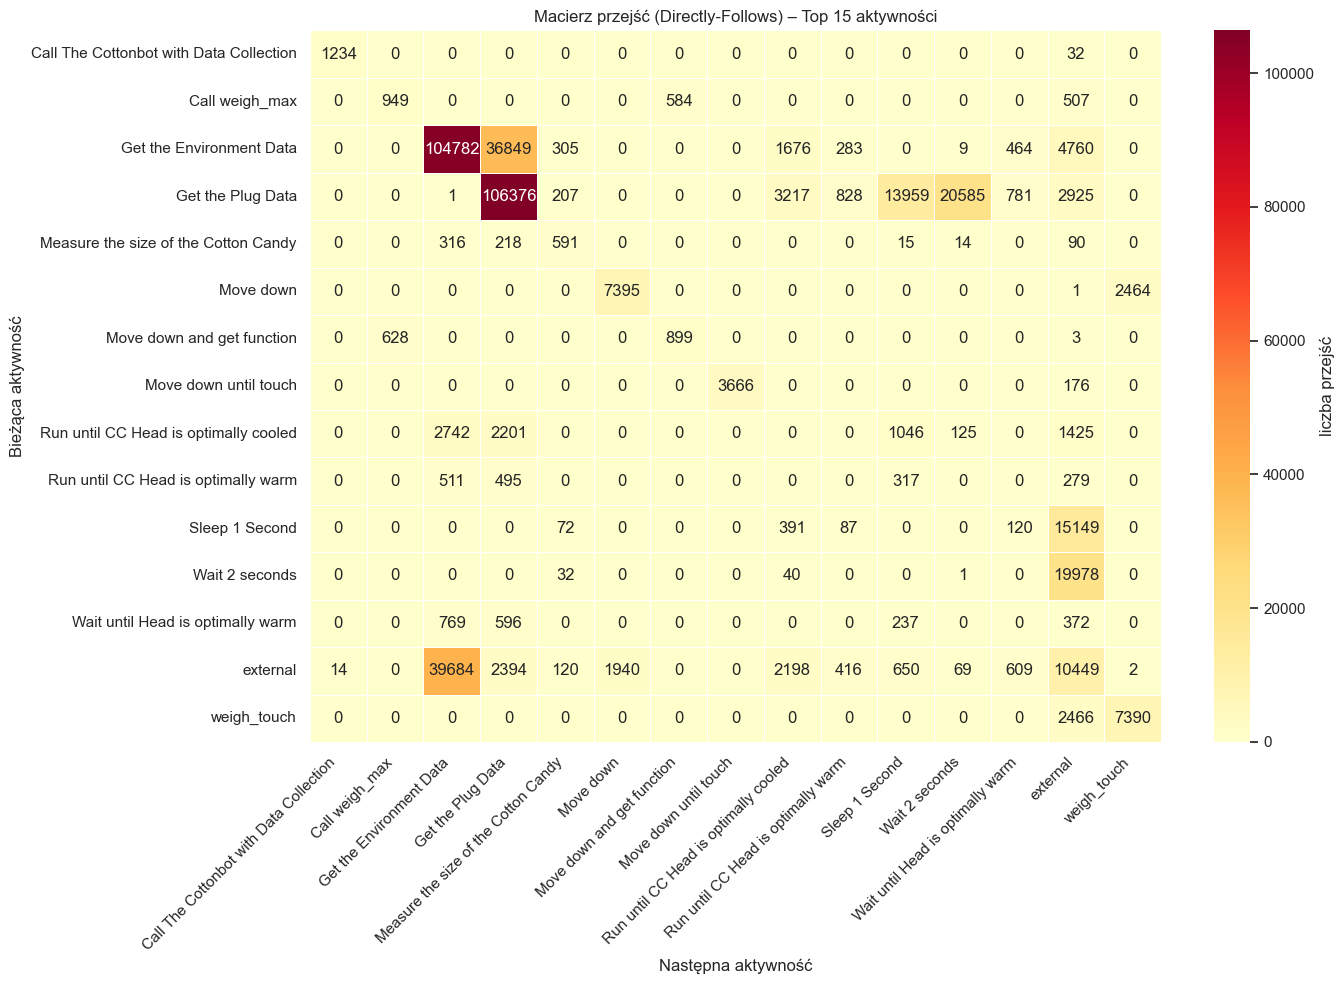

Top 20 najczęstszych przejść:
  Get the Plug Data                        → Get the Plug Data                        (106376)
  Get the Environment Data                 → Get the Environment Data                 (104782)
  external                                 → Get the Environment Data                 (39684)
  Get the Environment Data                 → Get the Plug Data                        (36849)
  Get the Plug Data                        → Wait 2 seconds                           (20585)
  Wait 2 seconds                           → external                                 (19978)
  Sleep 1 Second                           → external                                 (15149)
  Get the Plug Data                        → Sleep 1 Second                           (13959)
  external                                 → external                                 (10449)
  Move down                                → Move down                                (7395)
  weigh_touch                

/var/folders/ws/p5kx9dl15g1gyphfrcyg239w0000gn/T/ipykernel_77140/274474135.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tt_top, y="transition", x="time_to_next", orient="h", palette="Set2")


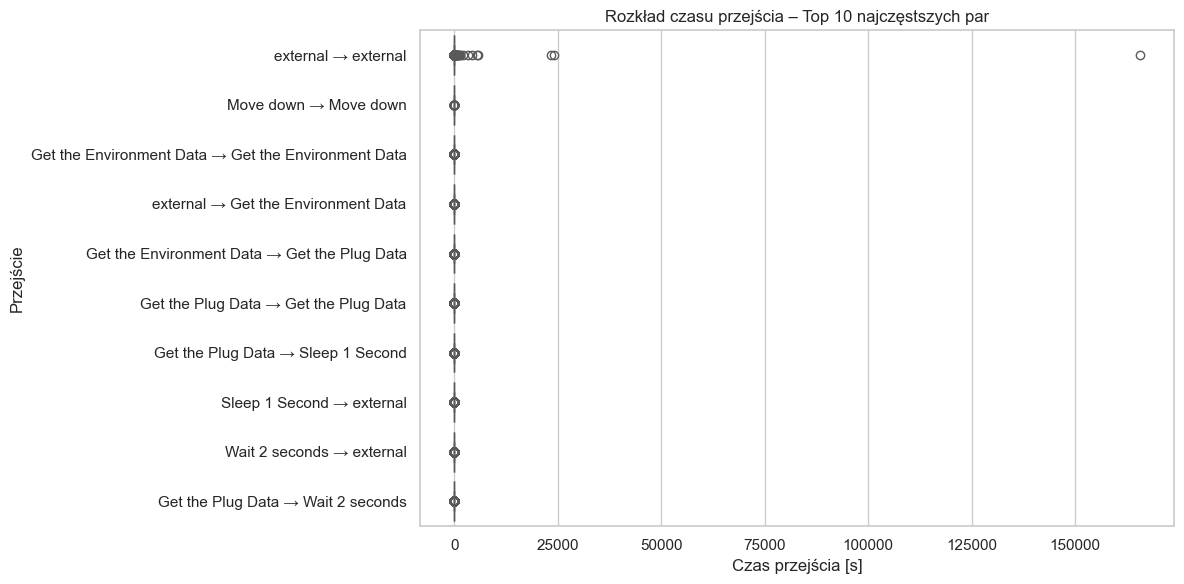

In [26]:
# === 6.1 Macierz przejść (Directly-Follows Graph) ===
df_sorted = df.sort_values(["case_id", "timestamp"]).copy()
df_sorted["next_activity"] = df_sorted.groupby("case_id")["activity_clean"].shift(-1)

# Filtrujemy tylko przejścia wewnątrz case
transitions = df_sorted.dropna(subset=["activity_clean", "next_activity"])
transition_counts = (
    transitions.groupby(["activity_clean", "next_activity"])
    .size()
    .reset_index(name="count")
)

# Top 15 aktywności do macierzy przejść (czytelna heatmapa)
top_acts = df["activity_clean"].value_counts().head(15).index.tolist()
trans_filtered = transition_counts[
    transition_counts["activity_clean"].isin(top_acts) &
    transition_counts["next_activity"].isin(top_acts)
]
trans_matrix = trans_filtered.pivot_table(
    index="activity_clean", columns="next_activity", values="count", fill_value=0
)

# pivot_table daje float; do annot z fmt='d' potrzebujemy int.
trans_matrix = trans_matrix.astype(int)

plt.figure(figsize=(14, 10))
sns.heatmap(trans_matrix, cmap="YlOrRd", linewidths=0.5,
            annot=True, fmt="d", cbar_kws={"label": "liczba przejść"})
plt.title("Macierz przejść (Directly-Follows) – Top 15 aktywności")
plt.xlabel("Następna aktywność")
plt.ylabel("Bieżąca aktywność")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# === 6.2 Top 20 najczęstszych przejść ===
print("Top 20 najczęstszych przejść:")
top_trans = transition_counts.sort_values("count", ascending=False).head(20)
for _, row in top_trans.iterrows():
    print(f"  {str(row['activity_clean']):40s} → {str(row['next_activity']):40s} ({row['count']})")

# === 6.3 Czas między zdarzeniami per typ przejścia ===
df_sorted["time_to_next"] = (
    df_sorted.groupby("case_id")["timestamp"]
    .diff(-1).abs().dt.total_seconds()
)
transition_times = df_sorted.dropna(subset=["next_activity", "time_to_next"]).copy()
transition_times["transition"] = (
    transition_times["activity_clean"].astype(str) + " → " + transition_times["next_activity"].astype(str)
)

# Top 10 najczęstszych przejść – rozkład czasu
top_10_trans = transition_times["transition"].value_counts().head(10).index
tt_top = transition_times[transition_times["transition"].isin(top_10_trans)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=tt_top, y="transition", x="time_to_next", orient="h", palette="Set2")
plt.xlabel("Czas przejścia [s]")
plt.ylabel("Przejście")
plt.title("Rozkład czasu przejścia – Top 10 najczęstszych par")
plt.tight_layout()
plt.show()

## 7. Identyfikacja wzorców czasowych

Analizujemy sezonowość i regularności w danych:
- rozkład zdarzeń wg **godziny dnia** i **dnia tygodnia**
- **heatmapa** dzień tygodnia × godzina
- **timeline dzienny** – jak zmienia się aktywność procesu w czasie
- porównanie metryk per batch (ewolucja procesu)

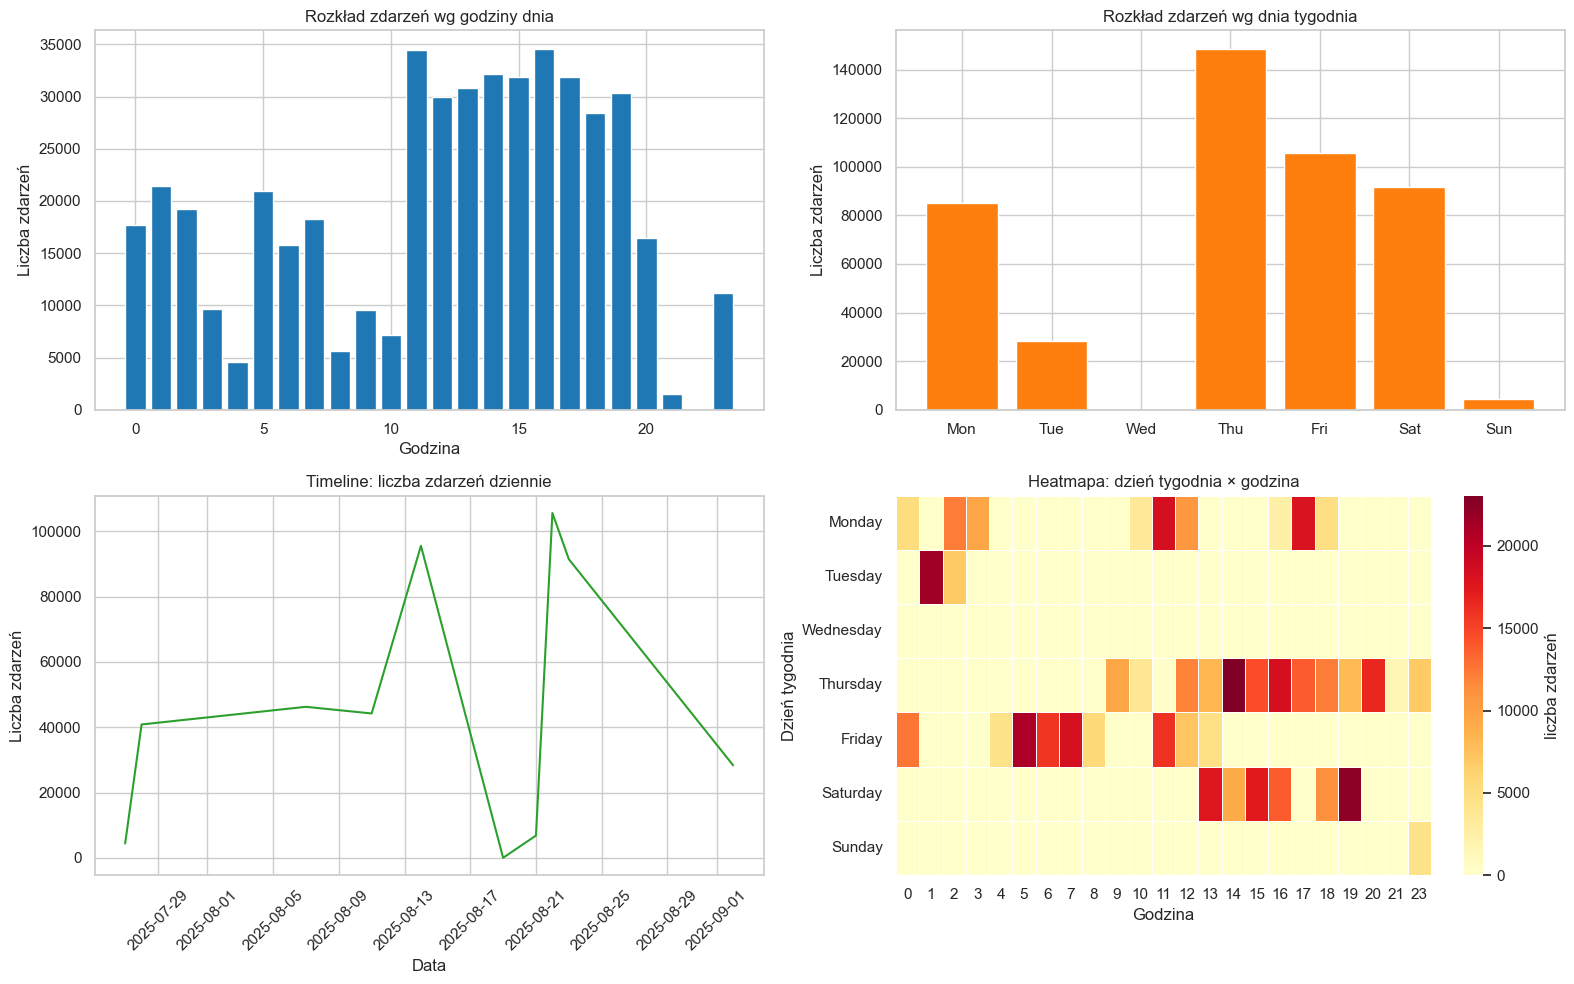

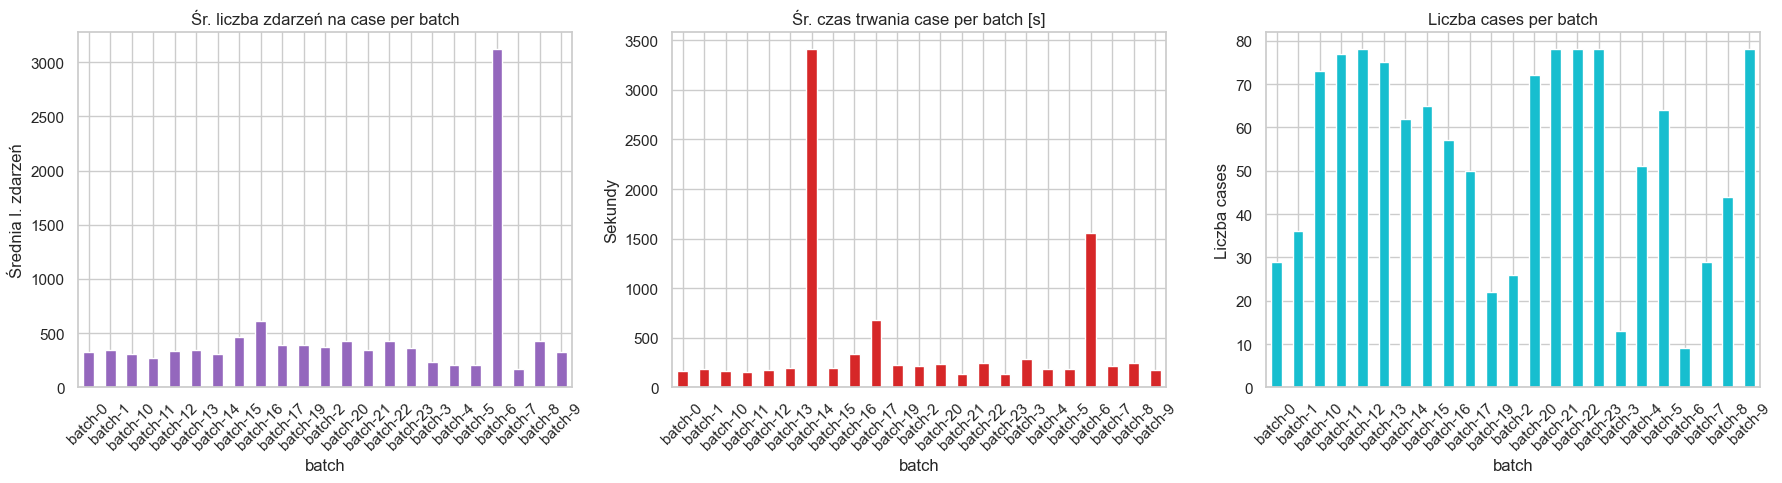

In [27]:
# === 7.1 Cechy temporalne zdarzeń ===
df["hour"] = df["timestamp"].dt.hour
df["dow"] = df["timestamp"].dt.day_name()
df["date"] = df["timestamp"].dt.date

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Godzina dnia
hourly = df["hour"].value_counts().sort_index()
axes[0, 0].bar(hourly.index, hourly.values, color="#1f77b4")
axes[0, 0].set_xlabel("Godzina")
axes[0, 0].set_ylabel("Liczba zdarzeń")
axes[0, 0].set_title("Rozkład zdarzeń wg godziny dnia")

# Dzień tygodnia
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = df["dow"].value_counts().reindex(dow_order).fillna(0)
axes[0, 1].bar(range(len(dow_order)), dow_counts.values, color="#ff7f0e")
axes[0, 1].set_xticks(range(len(dow_order)))
axes[0, 1].set_xticklabels([d[:3] for d in dow_order])
axes[0, 1].set_ylabel("Liczba zdarzeń")
axes[0, 1].set_title("Rozkład zdarzeń wg dnia tygodnia")

# Timeline dzienny
daily = df.groupby("date").size()
axes[1, 0].plot(daily.index, daily.values, color="#2ca02c")
axes[1, 0].set_xlabel("Data")
axes[1, 0].set_ylabel("Liczba zdarzeń")
axes[1, 0].set_title("Timeline: liczba zdarzeń dziennie")
axes[1, 0].tick_params(axis='x', rotation=45)

# Heatmapa: dzień tygodnia × godzina
heat_data = df.groupby(["dow", "hour"]).size().unstack(fill_value=0)
heat_data = heat_data.reindex(dow_order).fillna(0)
sns.heatmap(heat_data, cmap="YlOrRd", ax=axes[1, 1], linewidths=0.5,
            cbar_kws={"label": "liczba zdarzeń"})
axes[1, 1].set_title("Heatmapa: dzień tygodnia × godzina")
axes[1, 1].set_xlabel("Godzina")
axes[1, 1].set_ylabel("Dzień tygodnia")

plt.tight_layout()
plt.show()

# === 7.2 Ewolucja procesu w czasie (per batch) ===
batch_stats = case_stats.groupby("batch").agg(
    mean_events=("n_events", "mean"),
    mean_duration=("duration_sec", "mean"),
    n_cases=("case_id", "count"),
).sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

batch_stats["mean_events"].plot(kind="bar", ax=axes[0], color="#9467bd")
axes[0].set_title("Śr. liczba zdarzeń na case per batch")
axes[0].set_ylabel("Średnia l. zdarzeń")
axes[0].tick_params(axis='x', rotation=45)

batch_stats["mean_duration"].plot(kind="bar", ax=axes[1], color="#d62728")
axes[1].set_title("Śr. czas trwania case per batch [s]")
axes[1].set_ylabel("Sekundy")
axes[1].tick_params(axis='x', rotation=45)

batch_stats["n_cases"].plot(kind="bar", ax=axes[2], color="#17becf")
axes[2].set_title("Liczba cases per batch")
axes[2].set_ylabel("Liczba cases")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Analiza częstości ścieżek i najczęstszych wariantów

**Wariant procesu** = unikatowa sekwencja aktywności w ramach jednego case.

Analizujemy:
- ile jest unikalnych wariantów
- jakie warianty są najczęstsze
- ile wariantów potrzeba do pokrycia 80% / 95% przypadków
- rozkład długości wariantów (liczba kroków)

Liczba unikalnych wariantów: 261
Top 1 wariant obejmuje 165 cases (13.3%)

Top 15 wariantów (obejmuje 938/1244 cases):
   1. [ 165 cases] external → external → external → external → external → external → Initialize the sizes of the CC → Initialize the sizes ...
   2. [ 141 cases] external → external → external → external → external → external → Initialize Count → Initialize Count → Move down → Move...
   3. [  92 cases] external → external → external → external → external → external → Initialize the max pressure of the CC → Initialize the...
   4. [  91 cases] external → external → external → external → external → external → Initialize Vars → Initialize Vars → CUP_weight → CUP_w...
   5. [  70 cases] external → external → external → external → external → external → Initialize Vars → Initialize Vars → CUP_weight → CUP_w...
   6. [  63 cases] external → external → external → external → external → external → Initialize Count → Initialize Count → Move down → Move...
   7. [  56 cases] exte

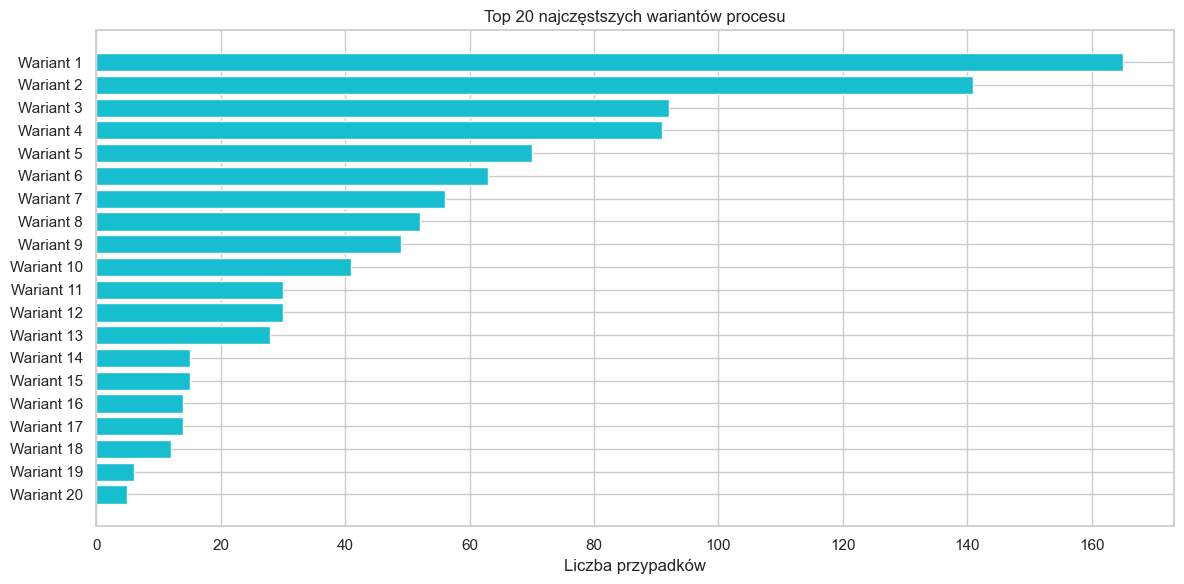


Warianty występujące 1 raz: 230 (88.1%)
Warianty występujące ≤5 razy: 242 (92.7%)
Wariantów do pokrycia 80% cases: 22
Wariantów do pokrycia 95% cases: 199


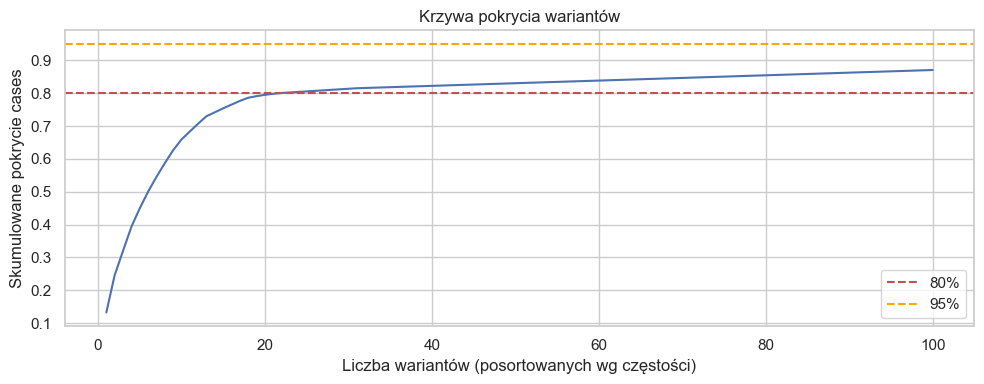

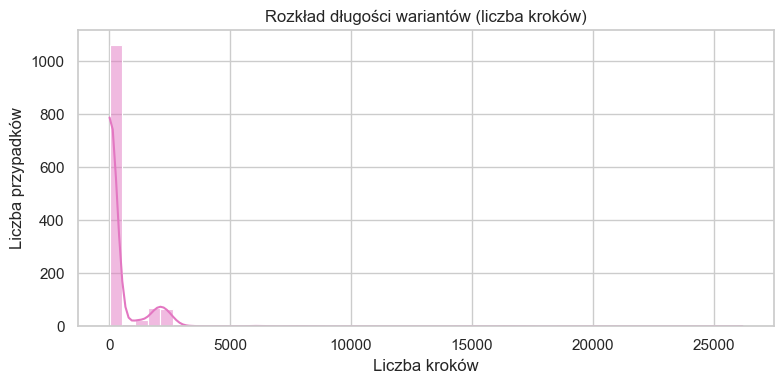

In [28]:
# === 8.1 Budowa wariantów (sekwencje aktywności per case) ===
case_variants = (
    df.sort_values(["case_id", "timestamp"])
    .groupby("case_id")["activity_clean"]
    .apply(lambda x: " → ".join(x.dropna().astype(str)))
    .rename("variant")
)

variant_counts = case_variants.value_counts()
print(f"Liczba unikalnych wariantów: {len(variant_counts)}")
print(f"Top 1 wariant obejmuje {variant_counts.iloc[0]} cases "
      f"({variant_counts.iloc[0]/len(case_variants)*100:.1f}%)")

# === 8.2 Top 15 wariantów ===
top_variants = variant_counts.head(15)
print(f"\nTop 15 wariantów (obejmuje {top_variants.sum()}/{len(case_variants)} cases):")
for i, (variant, count) in enumerate(top_variants.items(), 1):
    short = variant[:120] + "..." if len(variant) > 120 else variant
    print(f"  {i:2d}. [{count:4d} cases] {short}")

# Wizualizacja
top_n = min(20, len(variant_counts))
top_var_counts = variant_counts.head(top_n)

plt.figure(figsize=(12, 6))
plt.barh(range(top_n), top_var_counts.values, color="#17becf")
plt.yticks(range(top_n), [f"Wariant {i+1}" for i in range(top_n)])
plt.xlabel("Liczba przypadków")
plt.title(f"Top {top_n} najczęstszych wariantów procesu")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# === 8.3 Analiza ogona rozkładu wariantów ===
n_unique_single = (variant_counts == 1).sum()
n_unique_under5 = (variant_counts <= 5).sum()
print(f"\nWarianty występujące 1 raz: {n_unique_single} ({n_unique_single/len(variant_counts)*100:.1f}%)")
print(f"Warianty występujące ≤5 razy: {n_unique_under5} ({n_unique_under5/len(variant_counts)*100:.1f}%)")

# Krzywa pokrycia kumulatywnego
cumulative = variant_counts.cumsum() / variant_counts.sum()
n_80 = int((cumulative <= 0.8).sum()) + 1
n_95 = int((cumulative <= 0.95).sum()) + 1
print(f"Wariantów do pokrycia 80% cases: {n_80}")
print(f"Wariantów do pokrycia 95% cases: {n_95}")

plt.figure(figsize=(10, 4))
x_range = min(100, len(cumulative))
plt.plot(range(1, x_range + 1), cumulative.values[:x_range], 'b-')
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.xlabel("Liczba wariantów (posortowanych wg częstości)")
plt.ylabel("Skumulowane pokrycie cases")
plt.title("Krzywa pokrycia wariantów")
plt.legend()
plt.tight_layout()
plt.show()

# === 8.4 Rozkład długości wariantów ===
variant_lengths = (
    df.sort_values(["case_id", "timestamp"])
    .groupby("case_id")["activity_clean"]
    .count()
    .rename("variant_length")
)

plt.figure(figsize=(8, 4))
sns.histplot(variant_lengths, bins=50, kde=True, color="#e377c2")
plt.title("Rozkład długości wariantów (liczba kroków)")
plt.xlabel("Liczba kroków")
plt.ylabel("Liczba przypadków")
plt.tight_layout()
plt.show()

## 9. Wykrywanie anomalii

Stosujemy trzy niezależne metody wykrywania anomalii i porównujemy wyniki:
- **IQR** (z sekcji 3) – metoda statystyczna
- **Isolation Forest** (z sekcji 3) – drzewiasta metoda ensemble
- **Local Outlier Factor (LOF)** – metoda oparta na gęstości lokalnej

Anomalie konsensusowe = przypadki oznaczone przez ≥ 2 z 3 metod.

Dodatkowo identyfikujemy **rzadkie warianty** procesu jako potencjalne anomalie behawioralne.

LOF anomalie: 63 / 1244

Macierz nakładania się anomalii:
                    IQR  Isolation Forest   LOF
IQR               304.0              62.0  21.0
Isolation Forest   62.0              63.0   7.0
LOF                21.0               7.0  63.0

Anomalie konsensusowe (≥2 metody): 78 (6.3%)


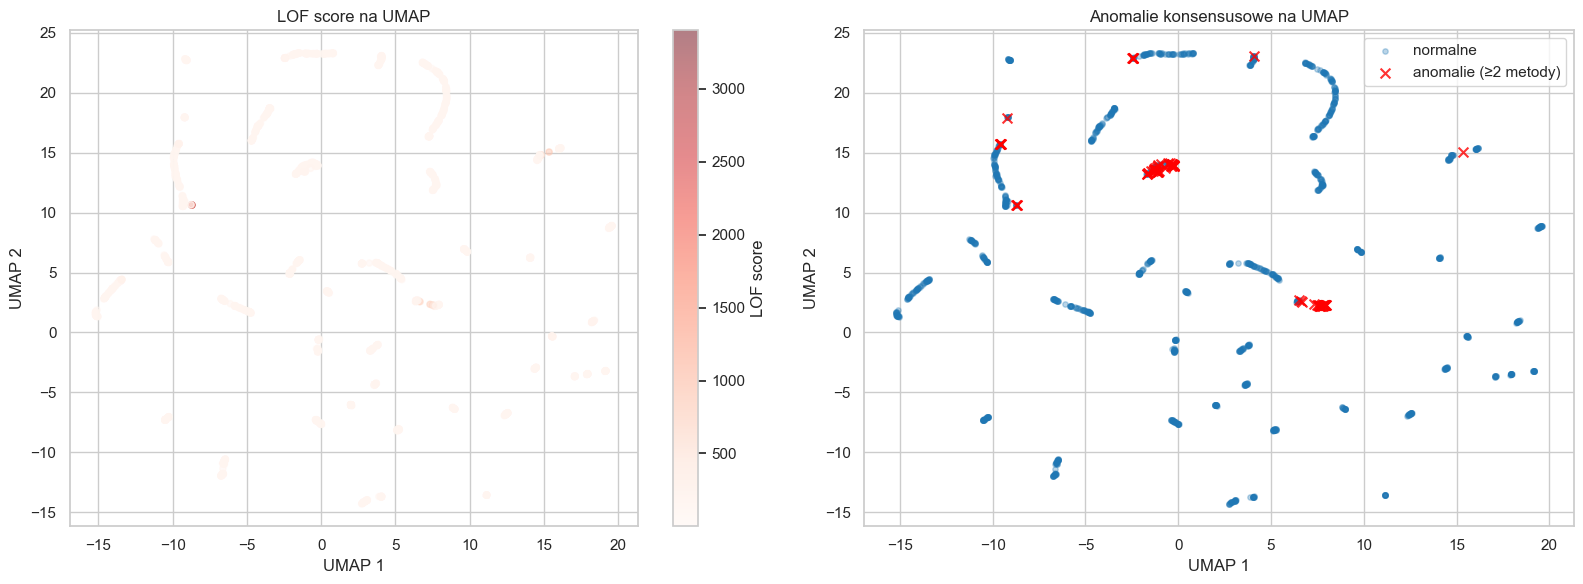


=== Profil anomalnych vs normalnych przypadków ===
         n_events                  n_unique_activities               duration_sec                   avg_gap_sec               
             mean  median      std                mean median    std         mean  median       std        mean median     std
Normalne   254.50    42.0   600.64                7.36    5.0   6.53        87.27   29.38    172.51        0.86   0.51    1.24
Anomalie  2137.85  2177.0  3582.85               18.14   23.0  11.33      4841.40  495.40  23334.20       27.87   0.24  140.66

Cases z rzadkimi wariantami (≤3 wystąpień): 251 (20.2%)
Rzadkie warianty ∩ anomalie konsensusowe: 76


In [29]:
# === 9.1 Local Outlier Factor ===
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
case_stats["lof_outlier"] = lof.fit_predict(X_scaled) == -1
lof_scores = -lof.negative_outlier_factor_
case_stats["lof_score"] = lof_scores

print(f"LOF anomalie: {case_stats['lof_outlier'].sum()} / {len(case_stats)}")

# === 9.2 Porównanie trzech metod ===
anomaly_methods = {
    "IQR": case_stats["iqr_outlier"],
    "Isolation Forest": case_stats["iso_outlier"],
    "LOF": case_stats["lof_outlier"],
}

overlap = pd.DataFrame(index=anomaly_methods.keys(), columns=anomaly_methods.keys(), dtype=int)
for m1, v1 in anomaly_methods.items():
    for m2, v2 in anomaly_methods.items():
        overlap.loc[m1, m2] = int((v1 & v2).sum())

print("\nMacierz nakładania się anomalii:")
print(overlap)

# Konsensus: ≥ 2 metody
case_stats["anomaly_consensus"] = (
    case_stats["iqr_outlier"].astype(int) +
    case_stats["iso_outlier"].astype(int) +
    case_stats["lof_outlier"].astype(int)
) >= 2

n_consensus = case_stats["anomaly_consensus"].sum()
print(f"\nAnomalie konsensusowe (≥2 metody): {n_consensus} ({n_consensus/len(case_stats)*100:.1f}%)")

# === 9.3 Wizualizacja anomalii na UMAP ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LOF score
sc = axes[0].scatter(X_umap[:, 0], X_umap[:, 1],
                     c=lof_scores, cmap="Reds", alpha=0.5, s=20)
plt.colorbar(sc, ax=axes[0], label="LOF score")
axes[0].set_title("LOF score na UMAP")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# Konsensus anomalii
normal = ~case_stats["anomaly_consensus"].values
axes[1].scatter(X_umap[normal, 0], X_umap[normal, 1],
                alpha=0.3, s=15, c="#1f77b4", label="normalne")
axes[1].scatter(X_umap[~normal, 0], X_umap[~normal, 1],
                alpha=0.8, s=50, c="red", marker="x", label="anomalie (≥2 metody)")
axes[1].set_title("Anomalie konsensusowe na UMAP")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend()

plt.tight_layout()
plt.show()

# === 9.4 Profil anomalnych vs normalnych ===
print("\n=== Profil anomalnych vs normalnych przypadków ===")
comparison = case_stats.groupby("anomaly_consensus")[
    ["n_events", "n_unique_activities", "duration_sec", "avg_gap_sec"]
].agg(["mean", "median", "std"])
comparison.index = ["Normalne", "Anomalie"]
print(comparison.round(2))

# === 9.5 Rzadkie warianty jako anomalie behawioralne ===
variant_freq_map = case_variants.map(variant_counts)
case_stats["variant_freq"] = variant_freq_map.reindex(case_stats["case_id"]).values

rare_threshold = 3
case_stats["rare_variant"] = case_stats["variant_freq"] <= rare_threshold
n_rare = case_stats["rare_variant"].sum()
print(f"\nCases z rzadkimi wariantami (≤{rare_threshold} wystąpień): "
      f"{n_rare} ({n_rare/len(case_stats)*100:.1f}%)")

# Czy rzadkie warianty pokrywają się z anomaliami?
rare_and_anomaly = (case_stats["rare_variant"] & case_stats["anomaly_consensus"]).sum()
print(f"Rzadkie warianty ∩ anomalie konsensusowe: {rare_and_anomaly}")

---

## 10. Wczytanie danych sensorowych

Dane sensorowe są przechowywane w plikach `*-process.yaml` w strukturze `stream:datastream`.
Każdy punkt pomiarowy zawiera:
- `stream:id` – identyfikator sensora (np. `temperature`, `humidity`, `head`, `power`, `current`, `ambient`)
- `stream:value` – wartość pomiaru
- `stream:timestamp` – czas pomiaru
- `stream:source` / `stream:group` – źródło i grupa sensora

W zbiorze danych cotton-candy dostępne są następujące sensory:

| Sensor | Opis | Liczba pomiarów |
|---|---|---|
| `temperature` | Temperatura otoczenia [°C] | ~9 434 |
| `humidity` | Wilgotność powietrza [%] | ~9 434 |
| `head` | Temperatura głowicy maszyny [°C] | ~4 717 |
| `ambient` | Temperatura ambient [°C] | ~4 717 |
| `current` | Prąd pobierany przez motor [A] | ~4 700 |
| `power` | Moc pobierana [W] | ~4 700 |
| `pos1/2/3` | Pozycja osi robota | ~82–135 |
| `weight` | Waga produktu [g] | ~68 |

In [30]:
# === 10. Wczytanie danych sensorowych z plików *-process.yaml ===
import yaml

def iter_event_docs(yaml_path: Path):
    """Generator: yields (event_dict, trace_case_uuid) for each event in *-process.yaml."""
    with yaml_path.open("r", encoding="utf-8") as f:
        docs = [d for d in yaml.safe_load_all(f) if isinstance(d, dict)]
    trace_case_uuid = None
    if docs and "log" in docs[0]:
        trace_case_uuid = (docs[0].get("log", {}).get("trace", {}) or {}).get("cpee:instance")
    for doc in docs[1:]:
        event = doc.get("event")
        if isinstance(event, dict):
            yield event, trace_case_uuid

def walk_datastream(node, current_group=None, current_source=None):
    """Rekurencyjnie przechodzi po stream:datastream i zwraca punkty pomiarowe."""
    if isinstance(node, list):
        local_group = current_group
        local_source = current_source
        for item in node:
            if isinstance(item, dict):
                local_group = item.get("stream:name", local_group)
                local_source = item.get("stream:source", local_source)
        for item in node:
            yield from walk_datastream(item, local_group, local_source)
        return
    if isinstance(node, dict):
        local_group = node.get("stream:name", current_group)
        local_source = node.get("stream:source", current_source)
        if "stream:point" in node:
            yield from walk_datastream(node["stream:point"], local_group, local_source)
        if "stream:id" in node and "stream:value" in node:
            yield {
                "sensor_group": local_group,
                "sensor_source": node.get("stream:source", local_source),
                "sensor_id": node.get("stream:id"),
                "sensor_timestamp_raw": node.get("stream:timestamp"),
                "sensor_value_raw": node.get("stream:value"),
            }
        for key, value in node.items():
            if key == "stream:point":
                continue
            if isinstance(value, (dict, list)):
                yield from walk_datastream(value, local_group, local_source)

# === Wczytanie ===
process_yaml_files = sorted(DATA_DIR.glob("batch-*/*-process.yaml"))
print(f"Pliki *-process.yaml: {len(process_yaml_files)}")

sensor_rows = []
for process_path in process_yaml_files:
    batch_name = process_path.parent.name
    for event, trace_case_uuid in iter_event_docs(process_path):
        case_id = event.get("cpee:instance") or trace_case_uuid
        event_name = event.get("concept:name")
        event_endpoint = event.get("concept:endpoint")
        event_time = pd.to_datetime(event.get("time:timestamp"), errors="coerce", utc=True)
        datastream = event.get("stream:datastream")
        if datastream is None:
            continue
        for point in walk_datastream(datastream):
            sensor_time = pd.to_datetime(point["sensor_timestamp_raw"], errors="coerce", utc=True)
            sensor_value_num = pd.to_numeric(point["sensor_value_raw"], errors="coerce")
            sensor_rows.append({
                "case_id": case_id,
                "batch": batch_name,
                "file_name": process_path.name,
                "event_name": event_name,
                "event_endpoint": event_endpoint,
                "event_time": event_time,
                "sensor_group": point["sensor_group"],
                "sensor_source": point["sensor_source"],
                "sensor_id": point["sensor_id"],
                "sensor_timestamp": sensor_time,
                "sensor_value_raw": point["sensor_value_raw"],
                "sensor_value": sensor_value_num,
            })

df_sensors = pd.DataFrame(sensor_rows)

# Czyszczenie identyfikatorów sensorów
df_sensors["sensor_id"] = df_sensors["sensor_id"].astype(str).str.strip()
df_sensors.loc[df_sensors["sensor_id"].isin(["", "None", "nan"]), "sensor_id"] = np.nan

print(f"\nWczytano {len(df_sensors)} punktów sensorowych")
print(f"Przypadki z danymi sensorowymi: {df_sensors['case_id'].nunique()}")
print(f"Typy sensorów (sensor_id): {df_sensors['sensor_id'].nunique()}")
print(f"Grupy sensorów (sensor_group): {df_sensors['sensor_group'].nunique()}")
print("\nRozkład rekordów per sensor:")
print(df_sensors["sensor_id"].dropna().value_counts())
df_sensors.head()

Pliki *-process.yaml: 33

Wczytano 38207 punktów sensorowych
Przypadki z danymi sensorowymi: 33
Typy sensorów (sensor_id): 11
Grupy sensorów (sensor_group): 7

Rozkład rekordów per sensor:
sensor_id
humidity       9434
temperature    9434
head           4717
ambient        4717
current        4700
power          4700
pos1            135
pos2             82
pos3             82
pressures        78
weight           68
Name: count, dtype: int64


,case_id,batch,file_name,event_name,event_endpoint,event_time,sensor_group,sensor_source,sensor_id,sensor_timestamp,sensor_value_raw,sensor_value
0,ac539644-d15f-47cb-be72-619ec2fb73eb,batch-0,0-0-process.yaml,Get the Environment Data,https://lab.bpm.in.tum.de/sugarpi/environment/,NaT,environment,sensors,humidity,2025-07-28 01:44:38.450000+00:00,63.73,63.73
1,ac539644-d15f-47cb-be72-619ec2fb73eb,batch-0,0-0-process.yaml,Get the Environment Data,https://lab.bpm.in.tum.de/sugarpi/environment/,NaT,environment,sensors,temperature,2025-07-28 01:44:38.450000+00:00,24.59,24.59
2,ac539644-d15f-47cb-be72-619ec2fb73eb,batch-0,0-0-process.yaml,Get the Environment Data,https://lab.bpm.in.tum.de/sugarpi/environment/,NaT,internal,sensors,humidity,2025-07-28 01:44:38.450000+00:00,39.26,39.26
3,ac539644-d15f-47cb-be72-619ec2fb73eb,batch-0,0-0-process.yaml,Get the Environment Data,https://lab.bpm.in.tum.de/sugarpi/environment/,NaT,internal,sensors,temperature,2025-07-28 01:44:38.450000+00:00,37.90,37.9
4,ac539644-d15f-47cb-be72-619ec2fb73eb,batch-0,0-0-process.yaml,Get the Environment Data,https://lab.bpm.in.tum.de/sugarpi/environment/,NaT,infrared,sensors,head,2025-07-28 01:44:38.450000+00:00,25.67,25.67


## 11. Eksploracja i jakość danych sensorowych

Analizujemy:
- częstość pomiarów per sensor (ile punktów ma każdy sensor)
- **jakość danych**: brakujące timestampy, wartości nienumeryczne, duplikaty
- **rozkład wartości** per sensor (boxploty, histogramy)
- porównanie średnich wartości per batch (czy parametry procesu zmieniały się w czasie)

=== Jakość danych sensorowych (całość) ===
Brakujące timestampy:   0 (0.0%)
Brakujące sensor_id:    60 (0.2%)
Wartości nienumeryczne: 303 (0.8%)
Duplikaty:              81 (0.2%)

=== Jakość danych per sensor ===
             records  missing_ts  non_numeric  missing_ts_pct  non_numeric_pct
sensor_id                                                                     
humidity        9434           0            0             0.0             0.00
temperature     9434           0            0             0.0             0.00
ambient         4717           0            0             0.0             0.00
head            4717           0            0             0.0             0.00
current         4700           0            0             0.0             0.00
power           4700           0            0             0.0             0.00
pos1             135           0           79             0.0            58.52
pos2              82           0           43             0.0            52.

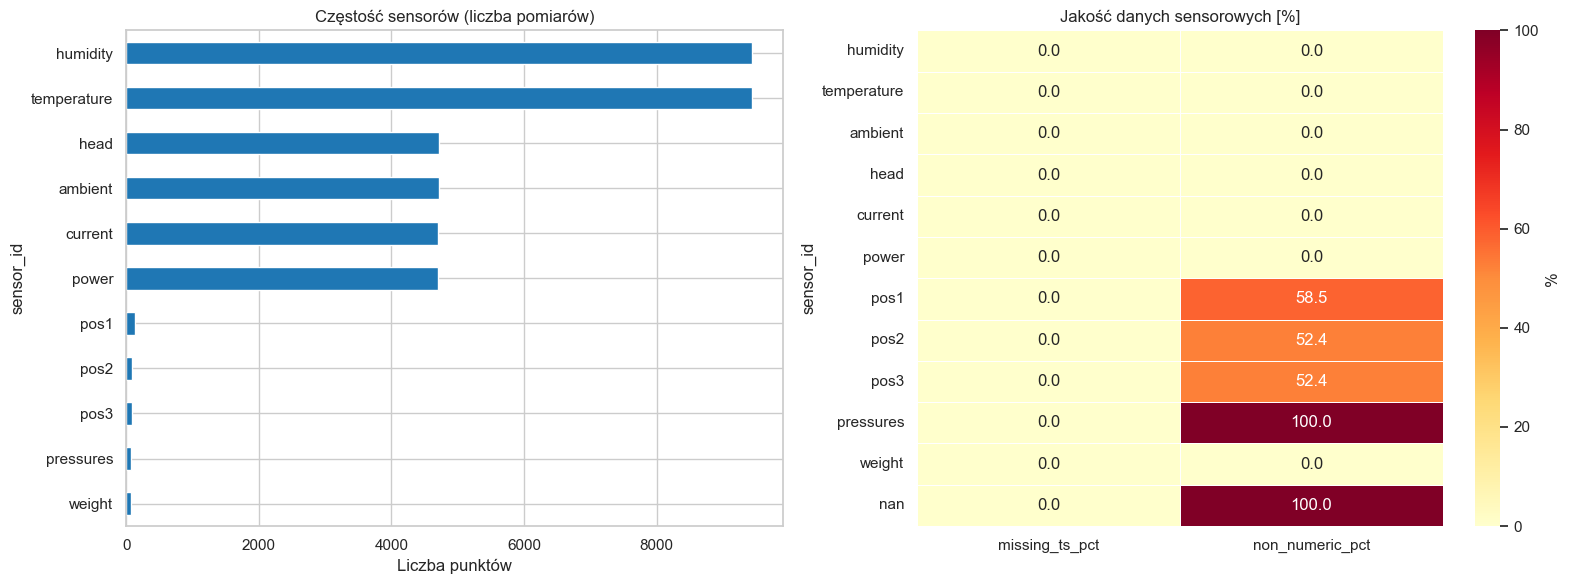

/var/folders/ws/p5kx9dl15g1gyphfrcyg239w0000gn/T/ipykernel_77140/374391289.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df_box, x="sensor_id", y="sensor_value",


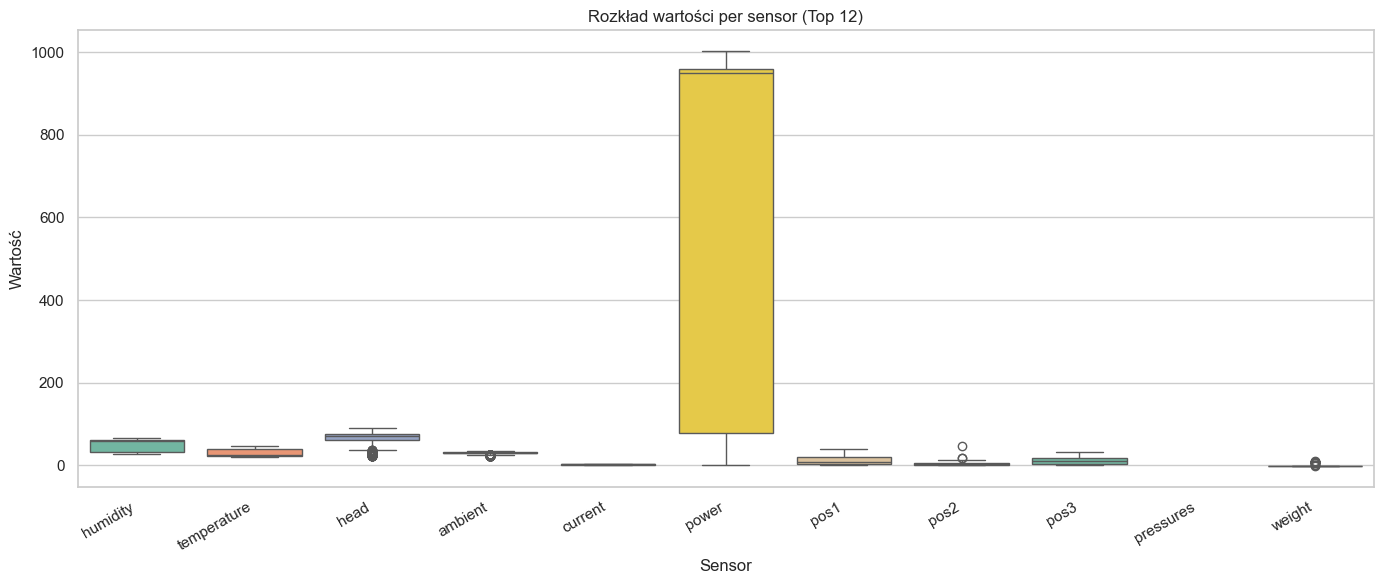

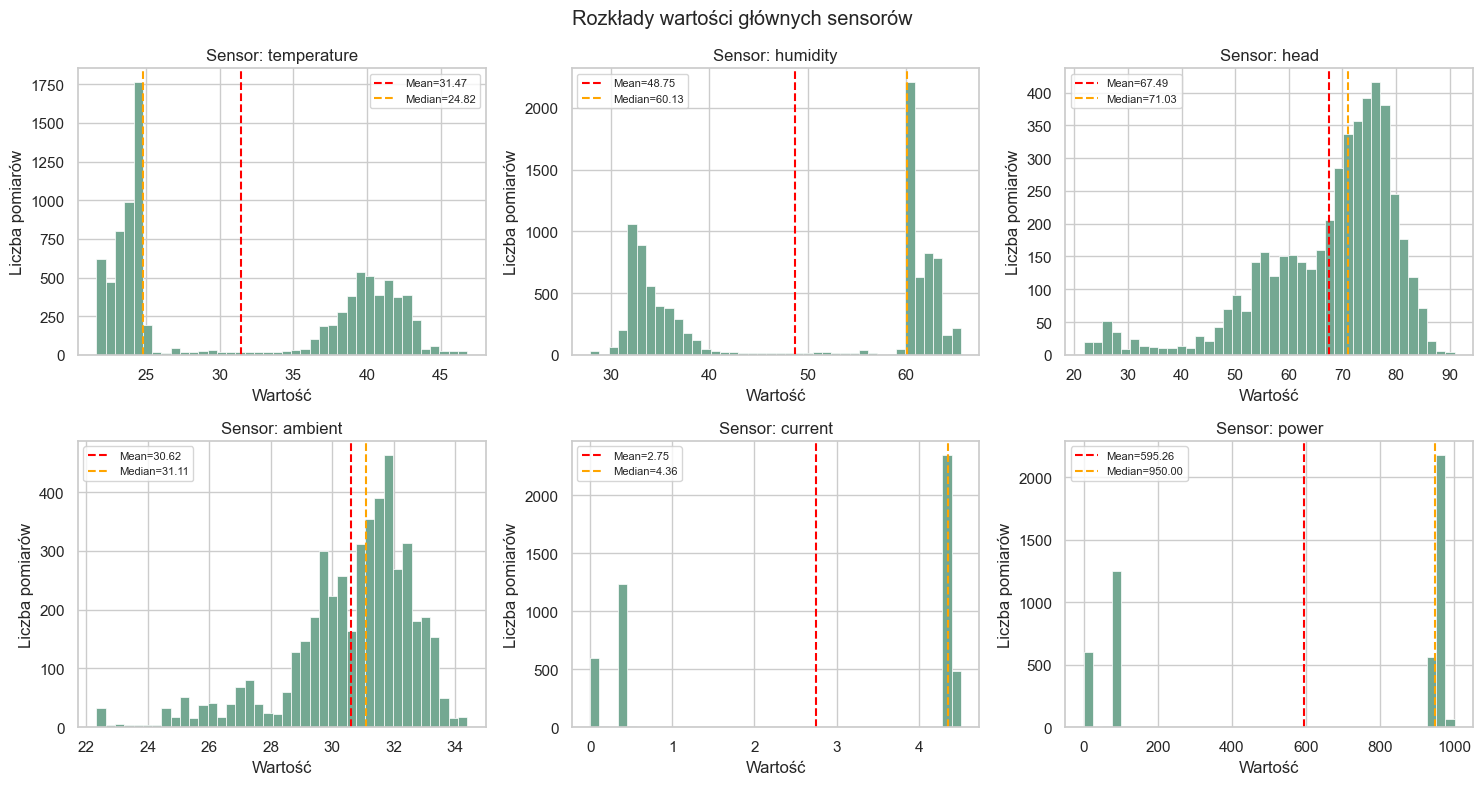

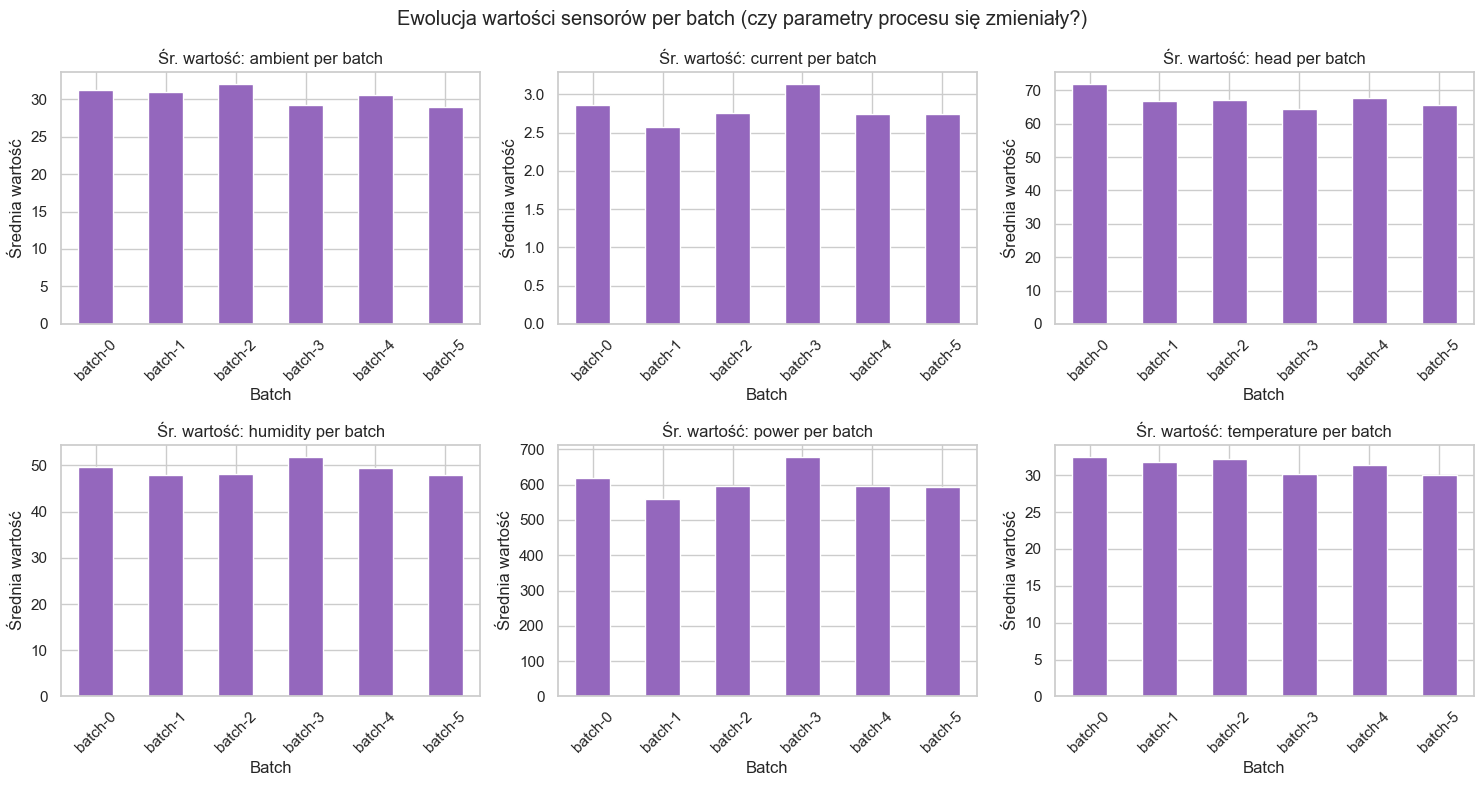

In [31]:
# === 11.1 Statystyki i jakość danych sensorowych ===

# Upewniamy się, że sensor_value jest numeryczny (YAML może zwracać mieszane typy)
df_sensors["sensor_value"] = pd.to_numeric(df_sensors["sensor_value"], errors="coerce")

sensor_freq = df_sensors["sensor_id"].dropna().value_counts()

# Jakość per sensor
missing_ts = df_sensors["sensor_timestamp"].isna().sum()
missing_id = df_sensors["sensor_id"].isna().sum()
non_numeric = df_sensors["sensor_value"].isna().sum()
dup_key = (
    df_sensors["case_id"].astype(str)
    + "|" + df_sensors["sensor_id"].astype(str)
    + "|" + df_sensors["sensor_timestamp"].astype(str)
    + "|" + df_sensors["sensor_value_raw"].map(lambda x: repr(x))
    + "|" + df_sensors["file_name"].astype(str)
)
duplicates = dup_key.duplicated().sum()

print("=== Jakość danych sensorowych (całość) ===")
print(f"Brakujące timestampy:   {missing_ts} ({missing_ts/len(df_sensors)*100:.1f}%)")
print(f"Brakujące sensor_id:    {missing_id} ({missing_id/len(df_sensors)*100:.1f}%)")
print(f"Wartości nienumeryczne: {non_numeric} ({non_numeric/len(df_sensors)*100:.1f}%)")
print(f"Duplikaty:              {duplicates} ({duplicates/len(df_sensors)*100:.1f}%)")

quality_by_sensor = (
    df_sensors.groupby("sensor_id", dropna=False)
    .agg(
        records=("sensor_id", "size"),
        missing_ts=("sensor_timestamp", lambda s: s.isna().sum()),
        non_numeric=("sensor_value", lambda s: s.isna().sum()),
    )
    .sort_values("records", ascending=False)
)
quality_by_sensor["missing_ts_pct"] = (quality_by_sensor["missing_ts"] / quality_by_sensor["records"] * 100).round(2)
quality_by_sensor["non_numeric_pct"] = (quality_by_sensor["non_numeric"] / quality_by_sensor["records"] * 100).round(2)
print("\n=== Jakość danych per sensor ===")
print(quality_by_sensor)

# Statystyki numeryczne
numeric_stats_sensors = (
    df_sensors.dropna(subset=["sensor_id", "sensor_value"])
    .groupby("sensor_id")["sensor_value"]
    .describe()
    [["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
    .sort_values("count", ascending=False)
)
print("\n=== Statystyki numeryczne per sensor ===")
print(numeric_stats_sensors.round(4))

# === 11.2 Wizualizacje ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frequency bar chart
sensor_freq.plot(kind="barh", ax=axes[0], color="#1f77b4")
axes[0].set_title("Częstość sensorów (liczba pomiarów)")
axes[0].set_xlabel("Liczba punktów")
axes[0].invert_yaxis()

# Heatmapa jakości
heat_q = quality_by_sensor[["missing_ts_pct", "non_numeric_pct"]]
sns.heatmap(heat_q, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
            cbar_kws={"label": "%"}, linewidths=0.5)
axes[1].set_title("Jakość danych sensorowych [%]")
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# === 11.3 Rozkład wartości per sensor (boxploty) ===
plot_sensors_list = sensor_freq.head(12).index.tolist()
plot_df_box = df_sensors[df_sensors["sensor_id"].isin(plot_sensors_list)].dropna(subset=["sensor_value"]).copy()

if not plot_df_box.empty:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=plot_df_box, x="sensor_id", y="sensor_value",
                order=plot_sensors_list, palette="Set2")
    plt.xticks(rotation=30, ha="right")
    plt.title("Rozkład wartości per sensor (Top 12)")
    plt.xlabel("Sensor")
    plt.ylabel("Wartość")
    plt.tight_layout()
    plt.show()

# === 11.4 Histogramy wartości dla głównych sensorów ===
main_sensors = ["temperature", "humidity", "head", "ambient", "current", "power"]
available_main = [s for s in main_sensors if s in set(df_sensors["sensor_id"].dropna())]

if available_main:
    n = len(available_main)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()
    for i, sid in enumerate(available_main):
        vals = df_sensors[df_sensors["sensor_id"] == sid]["sensor_value"].dropna()
        axes[i].hist(vals, bins=40, color="#74a892", edgecolor="white", linewidth=0.5)
        axes[i].axvline(vals.mean(), color="red", linestyle="--", label=f"Mean={vals.mean():.2f}")
        axes[i].axvline(vals.median(), color="orange", linestyle="--", label=f"Median={vals.median():.2f}")
        axes[i].set_title(f"Sensor: {sid}")
        axes[i].set_xlabel("Wartość")
        axes[i].set_ylabel("Liczba pomiarów")
        axes[i].legend(fontsize=8)
    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Rozkłady wartości głównych sensorów")
    plt.tight_layout()
    plt.show()

# === 11.5 Porównanie średnich per batch ===
sensor_batch_means = (
    df_sensors[df_sensors["sensor_id"].isin(available_main)]
    .dropna(subset=["sensor_value"])
    .groupby(["batch", "sensor_id"])["sensor_value"]
    .mean()
    .unstack("sensor_id")
    .sort_index()
)

if not sensor_batch_means.empty:
    n_s = len(sensor_batch_means.columns)
    ncols = 3
    nrows = (n_s + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()
    for i, sid in enumerate(sensor_batch_means.columns):
        sensor_batch_means[sid].plot(kind="bar", ax=axes[i], color="#9467bd")
        axes[i].set_title(f"Śr. wartość: {sid} per batch")
        axes[i].set_xlabel("Batch")
        axes[i].set_ylabel("Średnia wartość")
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(n_s, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Ewolucja wartości sensorów per batch (czy parametry procesu się zmieniały?)")
    plt.tight_layout()
    plt.show()

## 12. Analiza szeregów czasowych sensorów

Analizujemy jak wartości sensorów zmieniają się w czasie:
- **Timeline** per sensor (agregacja godzinowa) z rolling average (24h)
- **Zmienność** – Coefficient of Variation (CV) wskazuje, które sensory są najbardziej niestabilne
- **Sezonowość** – heatmapa dzień tygodnia × godzina per sensor
- **Rozkład czasów pomiarów** – jak często każdy sensor próbkuje dane

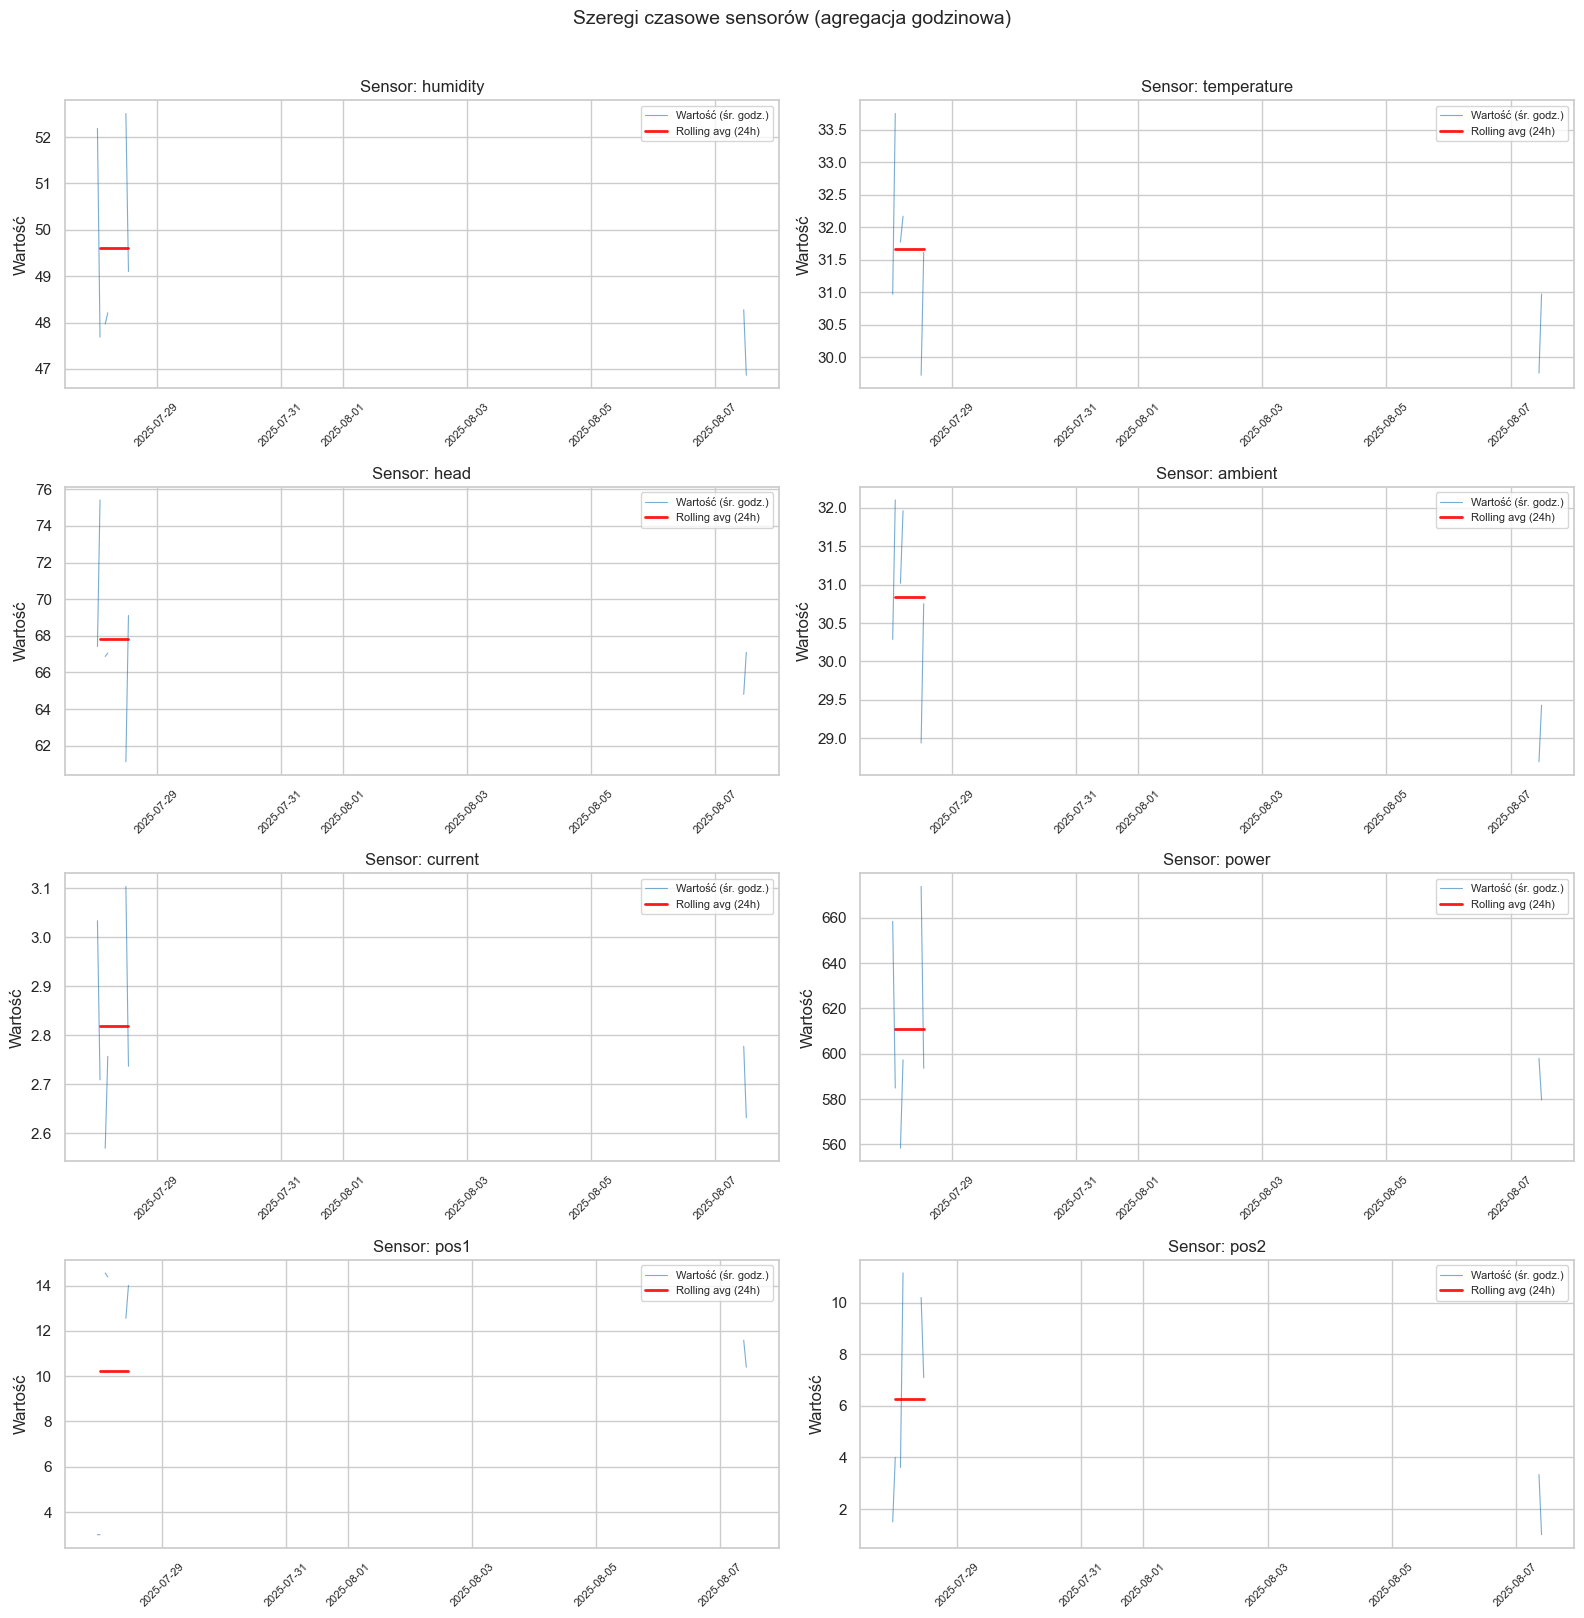

=== Zmienność sensorów ===
                 mean       std       cv       iqr  val_min   val_max
sensor_id                                                            
weight         0.2709    4.0928  15.1093    0.0200    -1.80     9.810
pos2           5.6254    8.3766   1.4891    5.9400     0.00    46.570
pos1          12.4168   11.3657   0.9153   17.3425     0.00    39.910
pos3          11.7364    9.3349   0.7954   15.0700     0.00    32.250
power        595.2636  444.1103   0.7461  882.0000     0.00  1002.000
current        2.7456    2.0221   0.7365    4.0280     0.00     4.514
humidity      48.7489   13.7127   0.2813   27.2600    27.89    65.560
temperature   31.4668    8.3662   0.2659   16.1600    21.64    46.810
head          67.4858   12.7546   0.1890   15.9400    21.77    90.930
ambient       30.6179    2.0835   0.0680    2.3400    22.33    34.390


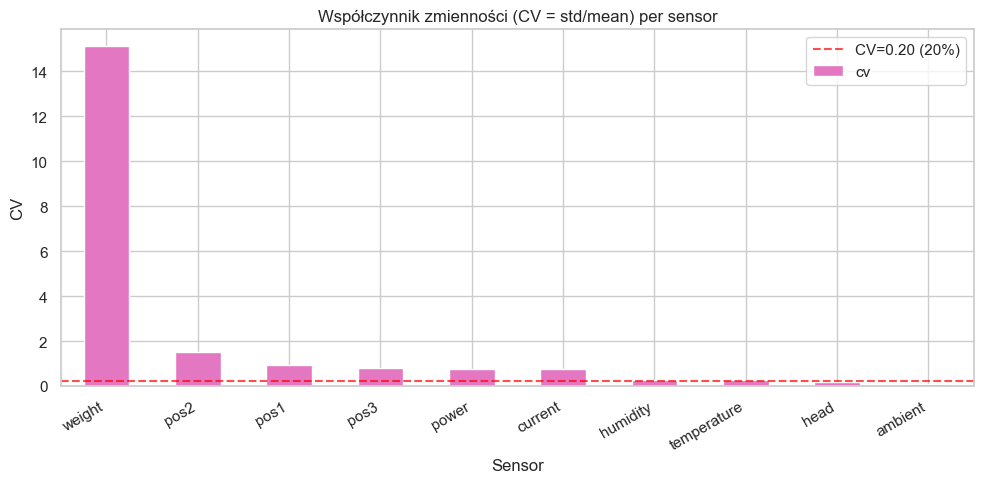

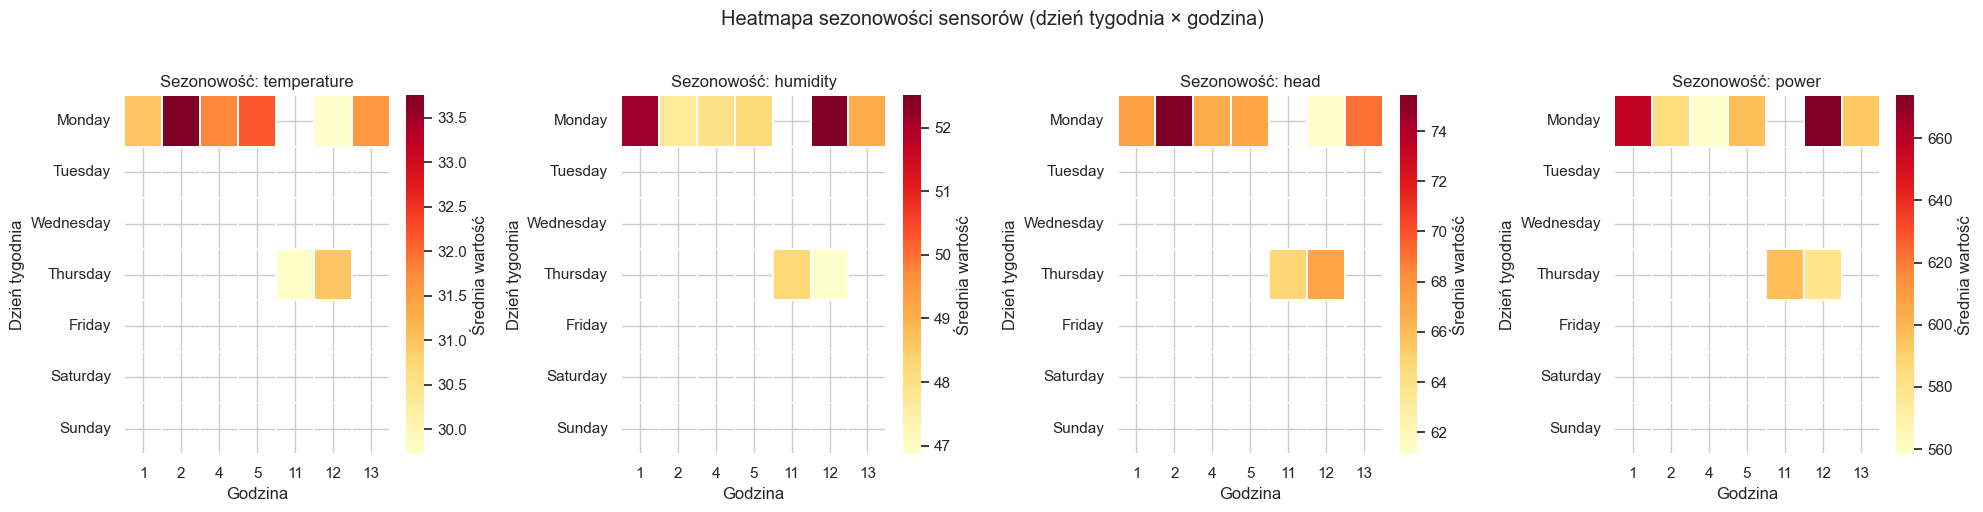

In [32]:
# === 12.1 Timeline per sensor (agregacja godzinowa + rolling average) ===

top_ts_sensors = sensor_freq.head(8).index.tolist()
df_ts = (
    df_sensors[df_sensors["sensor_id"].isin(top_ts_sensors)]
    .dropna(subset=["sensor_timestamp", "sensor_value"])
    .copy()
)

n_s = len(top_ts_sensors)
ncols = 2
nrows = (n_s + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, sid in enumerate(top_ts_sensors):
    ax = axes[i]
    ts_data = (
        df_ts[df_ts["sensor_id"] == sid]
        .set_index("sensor_timestamp")["sensor_value"]
        .sort_index()
    )
    ts_hourly = ts_data.resample("1h").mean()
    ax.plot(ts_hourly.index, ts_hourly.values, alpha=0.6, linewidth=0.8,
            color="#1f77b4", label="Wartość (śr. godz.)")
    if len(ts_hourly) >= 24:
        rolling_mean = ts_hourly.rolling(24, center=True, min_periods=6).mean()
        ax.plot(rolling_mean.index, rolling_mean.values,
                color="red", linewidth=2, alpha=0.9, label="Rolling avg (24h)")
    ax.set_title(f"Sensor: {sid}")
    ax.set_ylabel("Wartość")
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(fontsize=8)

for j in range(n_s, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Szeregi czasowe sensorów (agregacja godzinowa)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# === 12.2 Zmienność sensorów (Coefficient of Variation) ===
variability_stats = (
    df_sensors.dropna(subset=["sensor_id", "sensor_value"])
    .groupby("sensor_id")["sensor_value"]
    .agg(
        mean="mean",
        std="std",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        val_min="min",
        val_max="max",
    )
    .assign(cv=lambda d: (d["std"] / d["mean"].abs()).round(4),
            iqr=lambda d: d["q75"] - d["q25"])
    .sort_values("cv", ascending=False)
)
print("=== Zmienność sensorów ===")
print(variability_stats[["mean", "std", "cv", "iqr", "val_min", "val_max"]].round(4))

plt.figure(figsize=(10, 5))
variability_stats["cv"].dropna().sort_values(ascending=False).plot(
    kind="bar", color="#e377c2"
)
plt.title("Współczynnik zmienności (CV = std/mean) per sensor")
plt.ylabel("CV")
plt.xlabel("Sensor")
plt.xticks(rotation=30, ha="right")
plt.axhline(y=0.2, color="red", linestyle="--", alpha=0.7, label="CV=0.20 (20%)")
plt.legend()
plt.tight_layout()
plt.show()

# === 12.3 Heatmapa sezonowości: dzień tygodnia × godzina dla głównych sensorów ===
main_4 = [s for s in ["temperature", "humidity", "head", "power"] if s in set(df_sensors["sensor_id"].dropna())]

if main_4:
    fig, axes = plt.subplots(1, len(main_4), figsize=(5 * len(main_4), 5))
    if len(main_4) == 1:
        axes = [axes]
    dow_order_local = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    for ax, sid in zip(axes, main_4):
        s_data = df_sensors[(df_sensors["sensor_id"] == sid)].dropna(subset=["sensor_timestamp", "sensor_value"]).copy()
        s_data["dow"] = s_data["sensor_timestamp"].dt.day_name()
        s_data["hour"] = s_data["sensor_timestamp"].dt.hour
        heat = (
            s_data.groupby(["dow", "hour"])["sensor_value"]
            .mean()
            .unstack("hour")
            .reindex(dow_order_local)
        )
        sns.heatmap(heat, ax=ax, cmap="YlOrRd", linewidths=0.3,
                    cbar_kws={"label": "Średnia wartość"})
        ax.set_title(f"Sezonowość: {sid}")
        ax.set_xlabel("Godzina")
        ax.set_ylabel("Dzień tygodnia")
    plt.suptitle("Heatmapa sezonowości sensorów (dzień tygodnia × godzina)", y=1.02)
    plt.tight_layout()
    plt.show()

## 13. Korelacje i PCA na danych sensorowych

Budujemy **macierz cech sensorowych na poziomie przypadku** (case-level):
- dla każdego sensora i każdego case obliczamy: `mean`, `std`, `min`, `max`, `count`
- analizujemy **korelacje między sensorami** (czy temperatura i wilgotność są powiązane?)
- stosujemy **PCA** na cechach sensorowych, aby zobaczyć, ile wymiarów wystarczy
- wizualizujemy grupowanie cases w przestrzeni sensorowej (czy widać naturalne klastry?)

Macierz cech sensorowych: 33 cases × 50 cech
Cases z danymi sensorowymi: 33


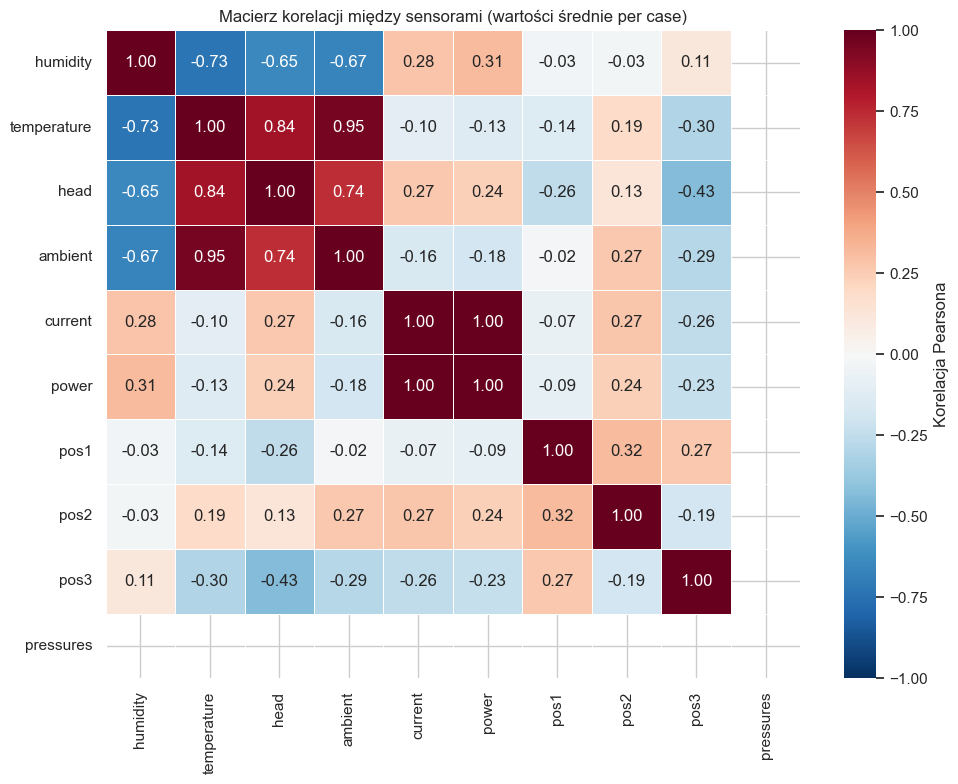


Top 10 korelacji między sensorami:
  current ↔ power : 0.997
  power ↔ current : 0.997
  ambient ↔ temperature : 0.954
  temperature ↔ ambient : 0.954
  temperature ↔ head : 0.838
  head ↔ temperature : 0.838
  ambient ↔ head : 0.738
  head ↔ ambient : 0.738
  humidity ↔ temperature : -0.729
  temperature ↔ humidity : -0.729


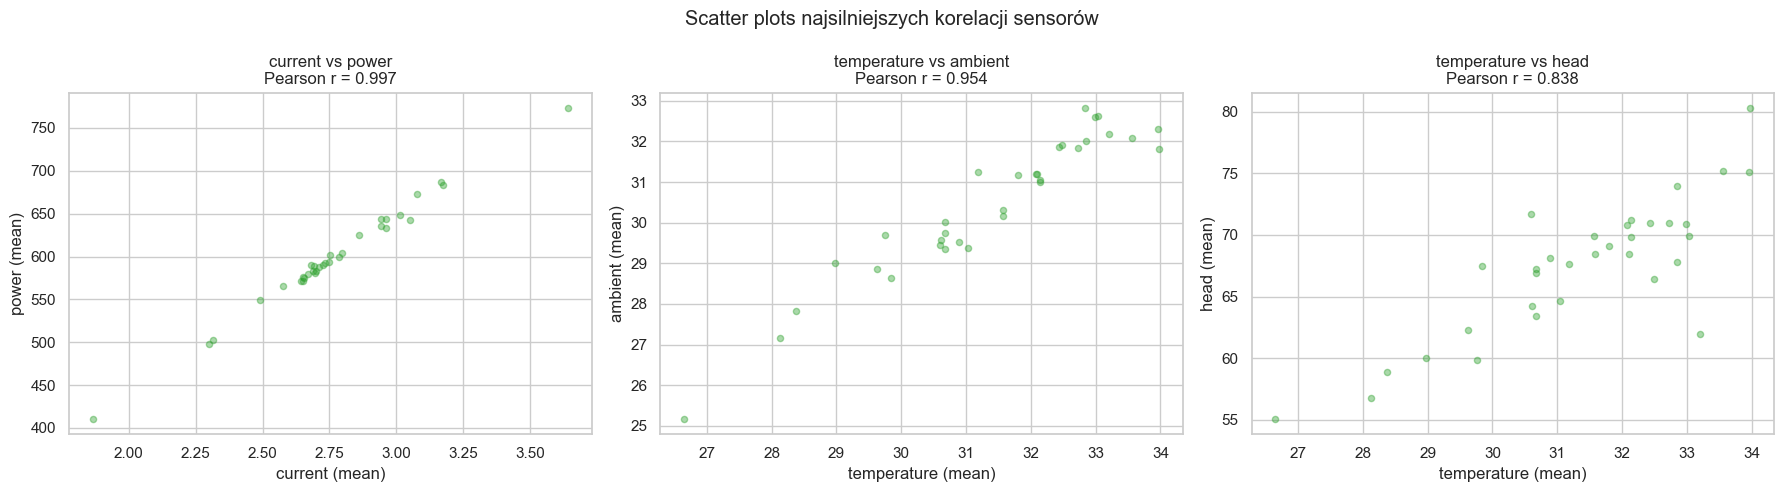


Cechy do PCA (po usunięciu stałych i pustych kolumn): 45
PCA na danych sensorowych: 8 komponentów
  → 8 komponentów wyjaśnia ≥90% wariancji
     PC1: 25.8%  (skum: 25.8%)
     PC2: 21.1%  (skum: 46.8%)
     PC3: 13.8%  (skum: 60.6%)
     PC4: 9.0%  (skum: 69.6%)
     PC5: 7.1%  (skum: 76.7%)
     PC6: 5.8%  (skum: 82.5%)
     PC7: 5.0%  (skum: 87.4%)
     PC8: 2.9%  (skum: 90.3%)


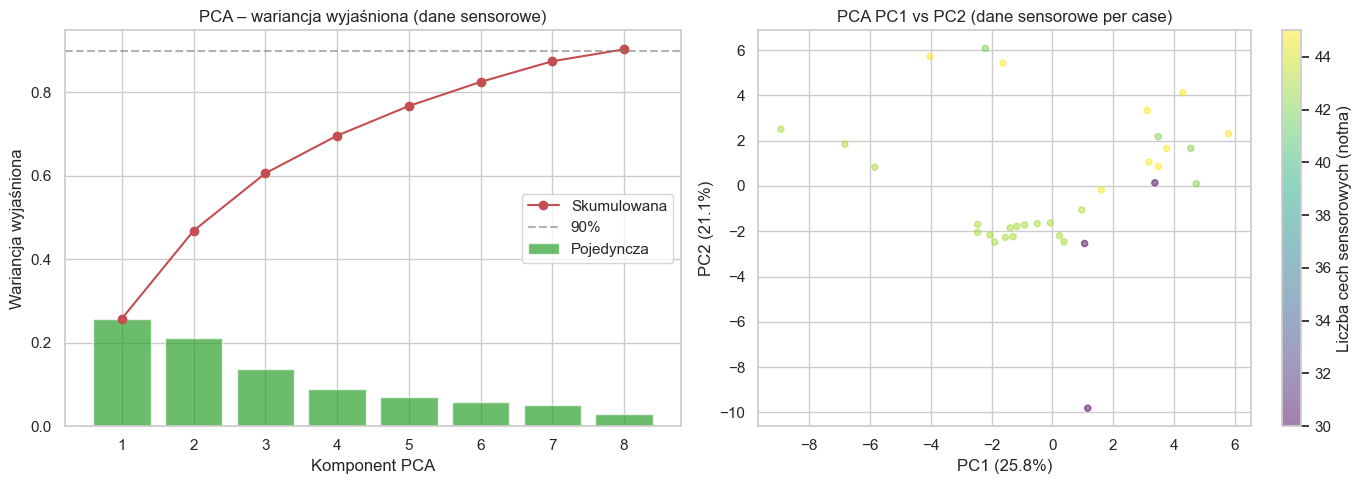


Top ładunki PCA (PC1 i PC2):
                     PC1     PC2
ambient_mean      0.2756 -0.0447
temperature_mean  0.2728 -0.0982
ambient_min       0.2615 -0.1129
ambient_max       0.2561  0.0653
temperature_max   0.2423 -0.0527
head_mean         0.2226 -0.1501
temperature_std   0.2163 -0.1930
head_min          0.2122 -0.2043
head_max          0.2066  0.0930
humidity_min     -0.2060  0.1287


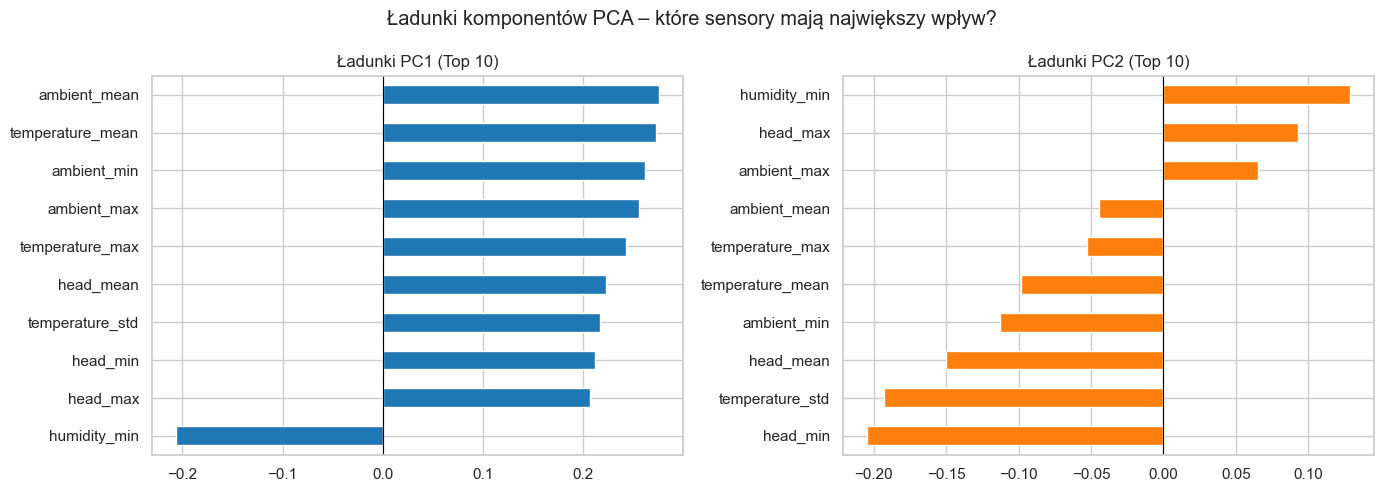

In [33]:
# === 13.1 Macierz cech sensorowych per case ===

top_sensors_for_feat = sensor_freq.head(10).index.tolist()

sensor_agg_parts = []
for sid in top_sensors_for_feat:
    sid_clean = re.sub(r"[^a-zA-Z0-9]", "_", str(sid))
    sid_data = (
        df_sensors[df_sensors["sensor_id"] == sid]
        .dropna(subset=["sensor_value"])
        .groupby("case_id")["sensor_value"]
        .agg(**{
            f"{sid_clean}_mean": "mean",
            f"{sid_clean}_std": "std",
            f"{sid_clean}_min": "min",
            f"{sid_clean}_max": "max",
            f"{sid_clean}_count": "count",
        })
    )
    sensor_agg_parts.append(sid_data)

if sensor_agg_parts:
    df_sensor_features = pd.concat(sensor_agg_parts, axis=1).reset_index()
    df_sensor_features.columns.name = None
    print(f"Macierz cech sensorowych: {df_sensor_features.shape[0]} cases × {df_sensor_features.shape[1] - 1} cech")
    print(f"Cases z danymi sensorowymi: {df_sensor_features['case_id'].nunique()}")

    # === 13.2 Macierz korelacji między wartościami średnimi sensorów ===
    mean_cols = [c for c in df_sensor_features.columns if c.endswith("_mean")]
    if len(mean_cols) >= 2:
        corr_matrix = df_sensor_features[mean_cols].corr()
        # Skróć nazwy kolumn do samego sensor_id
        short_labels = [c.replace("_mean", "") for c in mean_cols]
        corr_display = corr_matrix.copy()
        corr_display.index = short_labels
        corr_display.columns = short_labels

        plt.figure(figsize=(10, 8))
        sns.heatmap(
            corr_display, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"label": "Korelacja Pearsona"}
        )
        plt.title("Macierz korelacji między sensorami (wartości średnie per case)")
        plt.tight_layout()
        plt.show()

        # Top korelacje (bez diagonalnej)
        corr_vals = corr_matrix.where(
            ~np.eye(len(mean_cols), dtype=bool)
        ).stack().sort_values(key=abs, ascending=False)
        print("\nTop 10 korelacji między sensorami:")
        for (c1, c2), val in corr_vals.head(10).items():
            print(f"  {c1.replace('_mean','')} ↔ {c2.replace('_mean','')} : {val:.3f}")

    # === 13.3 Scatter plots dla najsilniej skorelowanych par ===
    if len(mean_cols) >= 2:
        # Weź top 3 pary (absolutna korelacja)
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
        top_pairs = upper.stack().abs().sort_values(ascending=False).head(3)

        n_pairs = len(top_pairs)
        fig, axes = plt.subplots(1, n_pairs, figsize=(6 * n_pairs, 5))
        if n_pairs == 1:
            axes = [axes]

        for ax, (c1, c2) in zip(axes, top_pairs.index):
            s1_name = c1.replace("_mean", "")
            s2_name = c2.replace("_mean", "")
            valid = df_sensor_features[[c1, c2]].dropna()
            ax.scatter(valid[c1], valid[c2], alpha=0.4, s=20, color="#2ca02c")
            corr_val = valid[c1].corr(valid[c2])
            ax.set_xlabel(f"{s1_name} (mean)")
            ax.set_ylabel(f"{s2_name} (mean)")
            ax.set_title(f"{s1_name} vs {s2_name}\nPearson r = {corr_val:.3f}")
        plt.suptitle("Scatter plots najsilniejszych korelacji sensorów")
        plt.tight_layout()
        plt.show()

    # === 13.4 PCA na cechach sensorowych ===
    feat_cols_pca = [c for c in df_sensor_features.columns if c != "case_id"]
    X_sensor = df_sensor_features[feat_cols_pca].copy()

    # Krok 1: usuń kolumny, które są w CAŁOŚCI NaN (brak danych → nie można imputować)
    X_sensor = X_sensor.dropna(axis=1, how="all")

    # Krok 2: wypełnij pozostałe NaN medianą kolumny (bardziej odporna na outliery niż mean)
    X_sensor = X_sensor.fillna(X_sensor.median())

    # Krok 3: usuń kolumny o zerowej wariancji (StandardScaler daje NaN dla const. kolumn)
    X_sensor = X_sensor.loc[:, X_sensor.std() > 0]

    feat_cols_pca_clean = list(X_sensor.columns)
    print(f"\nCechy do PCA (po usunięciu stałych i pustych kolumn): {len(feat_cols_pca_clean)}")

    if X_sensor.shape[1] >= 2 and X_sensor.shape[0] >= 5:
        from sklearn.preprocessing import StandardScaler
        scaler_s = StandardScaler()
        X_sensor_scaled = scaler_s.fit_transform(X_sensor)

        # Ostateczne zabezpieczenie: zamień ewentualne NaN/Inf na 0
        X_sensor_scaled = np.nan_to_num(X_sensor_scaled, nan=0.0, posinf=0.0, neginf=0.0)

        n_comp_s = min(8, X_sensor_scaled.shape[1])
        pca_s = PCA(n_components=n_comp_s, random_state=42)
        X_sensor_pca = pca_s.fit_transform(X_sensor_scaled)

        cumvar_s = np.cumsum(pca_s.explained_variance_ratio_)
        n90_s = int(np.argmax(cumvar_s >= 0.9)) + 1

        print(f"PCA na danych sensorowych: {n_comp_s} komponentów")
        print(f"  → {n90_s} komponentów wyjaśnia ≥90% wariancji")
        for i, (v, cv) in enumerate(zip(pca_s.explained_variance_ratio_, cumvar_s), 1):
            print(f"     PC{i}: {v*100:.1f}%  (skum: {cv*100:.1f}%)")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].bar(range(1, n_comp_s + 1), pca_s.explained_variance_ratio_,
                    alpha=0.7, color="#2ca02c", label="Pojedyncza")
        axes[0].plot(range(1, n_comp_s + 1), cumvar_s, "ro-", label="Skumulowana")
        axes[0].axhline(0.9, color="gray", linestyle="--", alpha=0.6, label="90%")
        axes[0].set_xlabel("Komponent PCA")
        axes[0].set_ylabel("Wariancja wyjaśniona")
        axes[0].set_title("PCA – wariancja wyjaśniona (dane sensorowe)")
        axes[0].legend()

        # Scatter PC1 vs PC2 – kolor = liczba pomiarów per case
        n_readings_per_case = df_sensor_features.drop(columns="case_id").notna().sum(axis=1)
        sc = axes[1].scatter(X_sensor_pca[:, 0], X_sensor_pca[:, 1],
                             c=n_readings_per_case, cmap="viridis", alpha=0.5, s=20)
        plt.colorbar(sc, ax=axes[1], label="Liczba cech sensorowych (notna)")
        axes[1].set_xlabel(f"PC1 ({pca_s.explained_variance_ratio_[0]*100:.1f}%)")
        axes[1].set_ylabel(f"PC2 ({pca_s.explained_variance_ratio_[1]*100:.1f}%)")
        axes[1].set_title("PCA PC1 vs PC2 (dane sensorowe per case)")
        plt.tight_layout()
        plt.show()

        # Ładunki PCA – które sensory dominują w PC1 i PC2?
        loadings = pd.DataFrame(
            pca_s.components_[:2].T,
            index=feat_cols_pca_clean,
            columns=["PC1", "PC2"]
        ).sort_values("PC1", key=abs, ascending=False)
        print("\nTop ładunki PCA (PC1 i PC2):")
        print(loadings.head(10).round(4))

        # Wizualizacja ładunków
        top_load = loadings.head(10)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        top_load["PC1"].sort_values().plot(kind="barh", ax=axes[0], color="#1f77b4")
        axes[0].set_title("Ładunki PC1 (Top 10)")
        axes[0].axvline(0, color="black", linewidth=0.8)
        top_load["PC2"].sort_values().plot(kind="barh", ax=axes[1], color="#ff7f0e")
        axes[1].set_title("Ładunki PC2 (Top 10)")
        axes[1].axvline(0, color="black", linewidth=0.8)
        plt.suptitle("Ładunki komponentów PCA – które sensory mają największy wpływ?")
        plt.tight_layout()
        plt.show()
    else:
        print("Za mało cech lub przypadków do PCA.")
else:
    print("Brak danych do budowy macierzy cech sensorowych.")

## 14. UMAP i klasteryzacja danych sensorowych

Po PCA stosujemy **UMAP** jako nieliniową metodę redukcji wymiarowości na cechach sensorowych per case, a następnie klasteryzujemy w tej przestrzeni.

**Cel:**
- **UMAP (2D)** – nieliniowe osadzenie cech sensorowych per case (zachowuje lokalne struktury lepiej niż PCA)
- **K-Means** – dobór optymalnego k metodą Silhouette; profil klastrów przez heatmapę
- **DBSCAN** – wykrywanie gęstościowych skupisk i identyfikacja outlierów sensorowych


UMAP sensorowy gotowy: (33, 2)
Optymalne k (UMAP sensorowy, Silhouette): 3  (score=0.442)
DBSCAN eps (auto, p90 k-NN): 0.949
DBSCAN (sensory): 1 klastrów, 0 punktów szumu


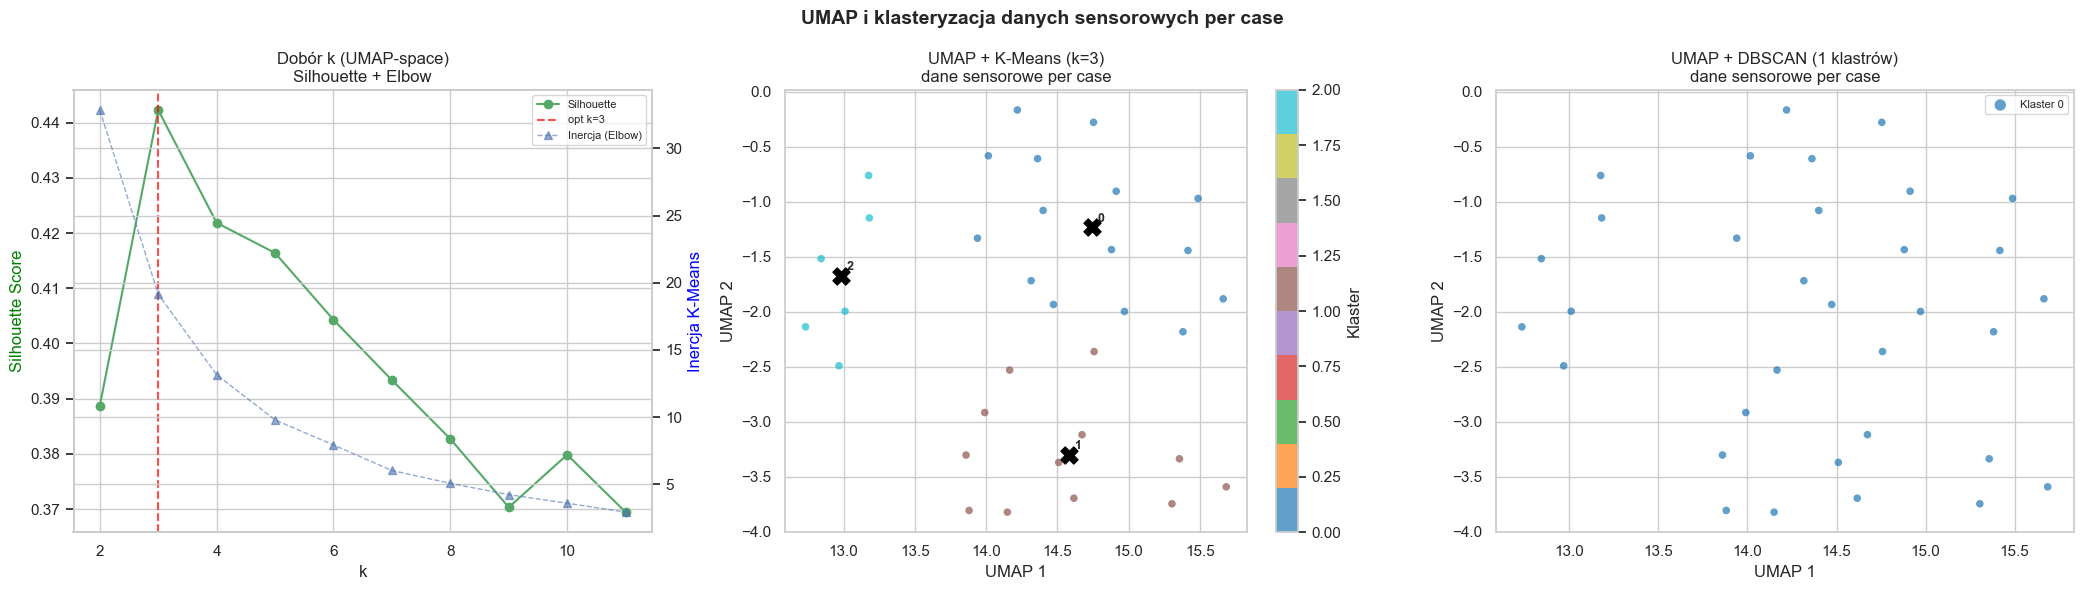


Profil klastrów sensorowych (K-Means, k=3):
                humidity  temperature   head  ambient  current   power   pos1  pos2   pos3  pressures
sensor_cluster                                                                                       
0                  47.81        31.29  68.59    30.17     2.82  609.85  13.31  5.45  13.22        NaN
1                  47.28        32.86  70.32    32.04     2.63  570.24  10.00  5.62   8.69        NaN
2                  53.61        28.59  58.82    27.96     2.91  632.69  11.76  4.01  15.01        NaN


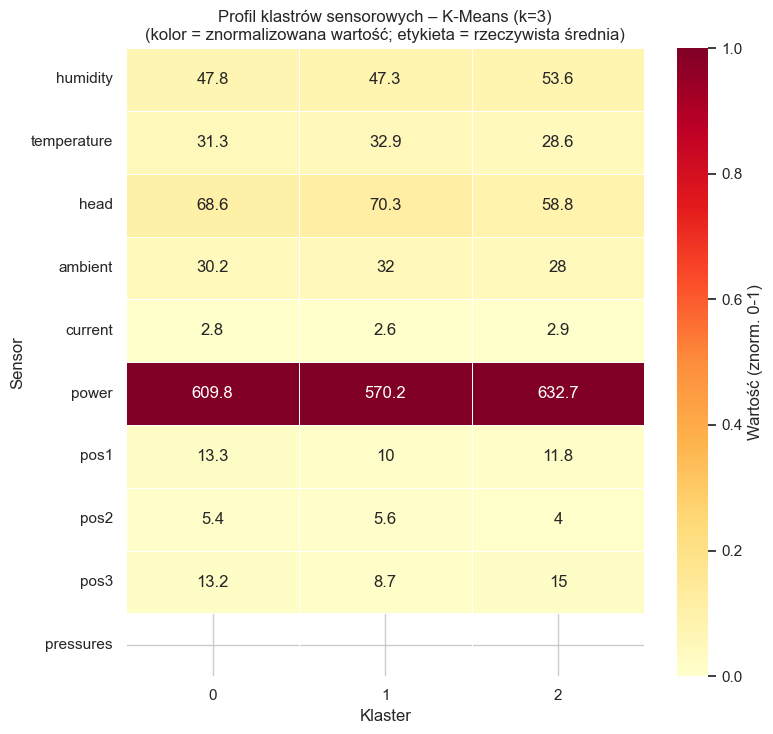


Rozmiary klastrów K-Means: {0: 15, 1: 12, 2: 6}
Rozmiary klastrów DBSCAN:  {0: 33}


In [36]:
# === 14. UMAP i klasteryzacja danych sensorowych ===
import warnings
warnings.filterwarnings("ignore", message=".*n_jobs.*")

if "X_sensor_scaled" not in dir() or X_sensor_scaled is None:
    print("Brak X_sensor_scaled – uruchom najpierw sekcję 13.")
elif X_sensor_scaled.shape[0] < 10:
    print(f"Za mało przypadków ({X_sensor_scaled.shape[0]}) do UMAP.")
else:
    from sklearn.metrics import silhouette_score as _sil
    from sklearn.preprocessing import MinMaxScaler as _MMS

    # --- 14.1 UMAP (2D) ---
    # min_dist=0.05 → ciasne skupiska, n_neighbors=20 → dobrze zachowana struktura globalna
    import umap as _umap
    reducer_s = _umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.05, random_state=42)
    X_sensor_umap = reducer_s.fit_transform(X_sensor_scaled)
    print(f"UMAP sensorowy gotowy: {X_sensor_umap.shape}")

    # --- 14.2 Dobór k – Silhouette NA PRZESTRZENI UMAP (nie na surowych cechach) ---
    # Klasteryzacja na 2D UMAP: odzwierciedla faktyczną strukturę wizualną, nie artefakt
    # wysokowymiarowej przestrzeni (gdzie Silhouette zawsze preferuje k=2).
    K_range_s = range(2, min(12, X_sensor_umap.shape[0] - 1))
    sil_s, inert_s = [], []
    for k_s in K_range_s:
        km_tmp = KMeans(n_clusters=k_s, random_state=42, n_init=15)
        lbl_tmp = km_tmp.fit_predict(X_sensor_umap)
        sil_s.append(_sil(X_sensor_umap, lbl_tmp))
        inert_s.append(km_tmp.inertia_)

    best_k_s = list(K_range_s)[int(np.argmax(sil_s))]
    print(f"Optymalne k (UMAP sensorowy, Silhouette): {best_k_s}  (score={max(sil_s):.3f})")

    # K-Means z optymalnym k na UMAP
    km_sensor = KMeans(n_clusters=best_k_s, random_state=42, n_init=15)
    sensor_clusters_km = km_sensor.fit_predict(X_sensor_umap)

    # --- 14.3 DBSCAN na przestrzeni UMAP ---
    # eps dobrany automatycznie jako percentyl odległości k-NN (heurystyka)
    from sklearn.neighbors import NearestNeighbors as _NNS
    nbrs_s = _NNS(n_neighbors=5).fit(X_sensor_umap)
    dists_s, _ = nbrs_s.kneighbors(X_sensor_umap)
    eps_auto = float(np.percentile(dists_s[:, -1], 90))
    print(f"DBSCAN eps (auto, p90 k-NN): {eps_auto:.3f}")

    dbscan_s = DBSCAN(eps=eps_auto, min_samples=5)
    sensor_clusters_db = dbscan_s.fit_predict(X_sensor_umap)
    n_db_s = len(set(sensor_clusters_db)) - (1 if -1 in sensor_clusters_db else 0)
    n_noise_s = (sensor_clusters_db == -1).sum()
    print(f"DBSCAN (sensory): {n_db_s} klastrów, {n_noise_s} punktów szumu")

    # --- 14.4 Wizualizacje: Silhouette + Elbow | UMAP K-Means | UMAP DBSCAN ---
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    # Silhouette score vs k + Elbow (inercja)
    ax_sil = axes[0]
    ax_elb = ax_sil.twinx()
    k_list = list(K_range_s)
    ax_sil.plot(k_list, sil_s, "go-", linewidth=1.5, label="Silhouette")
    ax_elb.plot(k_list, inert_s, "b^--", linewidth=1, alpha=0.6, label="Inercja (Elbow)")
    ax_sil.axvline(best_k_s, color="red", linestyle="--", alpha=0.7, label=f"opt k={best_k_s}")
    ax_sil.set_xlabel("k")
    ax_sil.set_ylabel("Silhouette Score", color="green")
    ax_elb.set_ylabel("Inercja K-Means", color="blue")
    ax_sil.set_title("Dobór k (UMAP-space)\nSilhouette + Elbow")
    lines1, labels1 = ax_sil.get_legend_handles_labels()
    lines2, labels2 = ax_elb.get_legend_handles_labels()
    ax_sil.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

    # UMAP + K-Means
    sc_km = axes[1].scatter(
        X_sensor_umap[:, 0], X_sensor_umap[:, 1],
        c=sensor_clusters_km, cmap="tab10", alpha=0.7, s=30, edgecolors="none"
    )
    plt.colorbar(sc_km, ax=axes[1], label="Klaster")
    # Zaznacz centroidy w przestrzeni UMAP
    for ci in range(best_k_s):
        pts = X_sensor_umap[sensor_clusters_km == ci]
        cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
        axes[1].scatter(cx, cy, marker="X", s=150, c="black", zorder=5)
        axes[1].annotate(str(ci), (cx, cy), textcoords="offset points",
                         xytext=(4, 4), fontsize=9, fontweight="bold")
    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")
    axes[1].set_title(f"UMAP + K-Means (k={best_k_s})\ndane sensorowe per case")

    # UMAP + DBSCAN
    unique_labels_s = sorted(set(sensor_clusters_db))
    cmap_db = plt.cm.tab10
    for lbl in unique_labels_s:
        mask_db = sensor_clusters_db == lbl
        col_db = cmap_db(lbl % 10) if lbl != -1 else (0.55, 0.55, 0.55, 1)
        lbl_name = f"Klaster {lbl}" if lbl != -1 else f"Szum ({n_noise_s})"
        alp_db = 0.7 if lbl != -1 else 0.25
        sz_db = 30 if lbl != -1 else 15
        axes[2].scatter(
            X_sensor_umap[mask_db, 0], X_sensor_umap[mask_db, 1],
            color=col_db, alpha=alp_db, s=sz_db, label=lbl_name, edgecolors="none"
        )
    axes[2].set_xlabel("UMAP 1")
    axes[2].set_ylabel("UMAP 2")
    axes[2].set_title(f"UMAP + DBSCAN ({n_db_s} klastrów)\ndane sensorowe per case")
    axes[2].legend(markerscale=1.5, fontsize=8, ncol=2)

    plt.suptitle("UMAP i klasteryzacja danych sensorowych per case", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # --- 14.5 Heatmapa profilu klastrów K-Means ---
    df_sensor_features["sensor_cluster"] = sensor_clusters_km
    mean_cols_s = [c for c in df_sensor_features.columns if c.endswith("_mean")]

    if mean_cols_s:
        cluster_sensor_profile = (
            df_sensor_features.groupby("sensor_cluster")[mean_cols_s]
            .mean()
            .round(2)
        )
        cluster_sensor_profile.columns = [c.replace("_mean", "") for c in cluster_sensor_profile.columns]

        print(f"\nProfil klastrów sensorowych (K-Means, k={best_k_s}):")
        print(cluster_sensor_profile.to_string())

        fig2, ax2 = plt.subplots(figsize=(max(8, best_k_s * 1.4), max(5, len(mean_cols_s) * 0.55 + 2)))
        norm_profile = pd.DataFrame(
            _MMS().fit_transform(cluster_sensor_profile.T),
            index=cluster_sensor_profile.columns,
            columns=cluster_sensor_profile.index
        )
        sns.heatmap(
            norm_profile, annot=cluster_sensor_profile.T.round(1),
            fmt="g", cmap="YlOrRd", linewidths=0.4,
            cbar_kws={"label": "Wartość (znorm. 0-1)"},
            ax=ax2
        )
        ax2.set_title(
            f"Profil klastrów sensorowych – K-Means (k={best_k_s})\n"
            "(kolor = znormalizowana wartość; etykieta = rzeczywista średnia)"
        )
        ax2.set_xlabel("Klaster")
        ax2.set_ylabel("Sensor")
        plt.tight_layout()
        plt.show()

    # --- 14.6 Rozmiary klastrów ---
    km_sizes = pd.Series(sensor_clusters_km).value_counts().sort_index()
    db_sizes = pd.Series(sensor_clusters_db).value_counts().sort_index()
    print(f"\nRozmiary klastrów K-Means: {km_sizes.to_dict()}")
    print(f"Rozmiary klastrów DBSCAN:  {db_sizes.to_dict()}")


## 15. Wykrywanie anomalii w danych sensorowych

Stosujemy dwa poziomy wykrywania anomalii:

**Poziom punktu pomiarowego (per reading):**
- **IQR** per sensor – identyfikuje odczyty leżące poza 1.5×IQR (klasyczna metoda)
- Wizualizacja boxplotów z zaznaczonymi outlierami

**Poziom przypadku (case-level):**
- **Isolation Forest** na macierzy cech sensorowych per case – detekcja przypadków z nietypowym profilem sensorowym
- **Powiązanie z anomaliami z logu zdarzeń** (sekcja 9) – czy przypadki anomalne w logu mają też anomalne odczyty sensorowe?

Wynik: ranking przypadków pod kątem anomalności sensorowej + tabela krzyżowa anomalie-log × anomalie-sensorowe.


=== Anomalie IQR per sensor ===
             n_records  n_outliers  outlier_pct  lower_bound  upper_bound      Q1        Q3
pos2              39.0         3.0         7.69      -7.9100      15.8500   1.000    6.9400
ambient         4717.0       246.0         5.22      26.1400      35.5000  29.650   31.9900
head            4717.0       187.0         3.96      36.5600     100.3200  60.470   76.4100
humidity        9434.0         0.0         0.00      -7.2000     101.8400  33.690   60.9500
temperature     9434.0         0.0         0.00      -0.3100      64.3300  23.930   40.0900
current         4700.0         0.0         0.00      -5.6900      10.4220   0.352    4.3800
power           4700.0         0.0         0.00   -1245.0000    2283.0000  78.000  960.0000
pos1              56.0         0.0         0.00     -22.0138      47.3563   4.000   21.3425
pos3              39.0         0.0         0.00     -19.6050      40.6750   3.000   18.0700


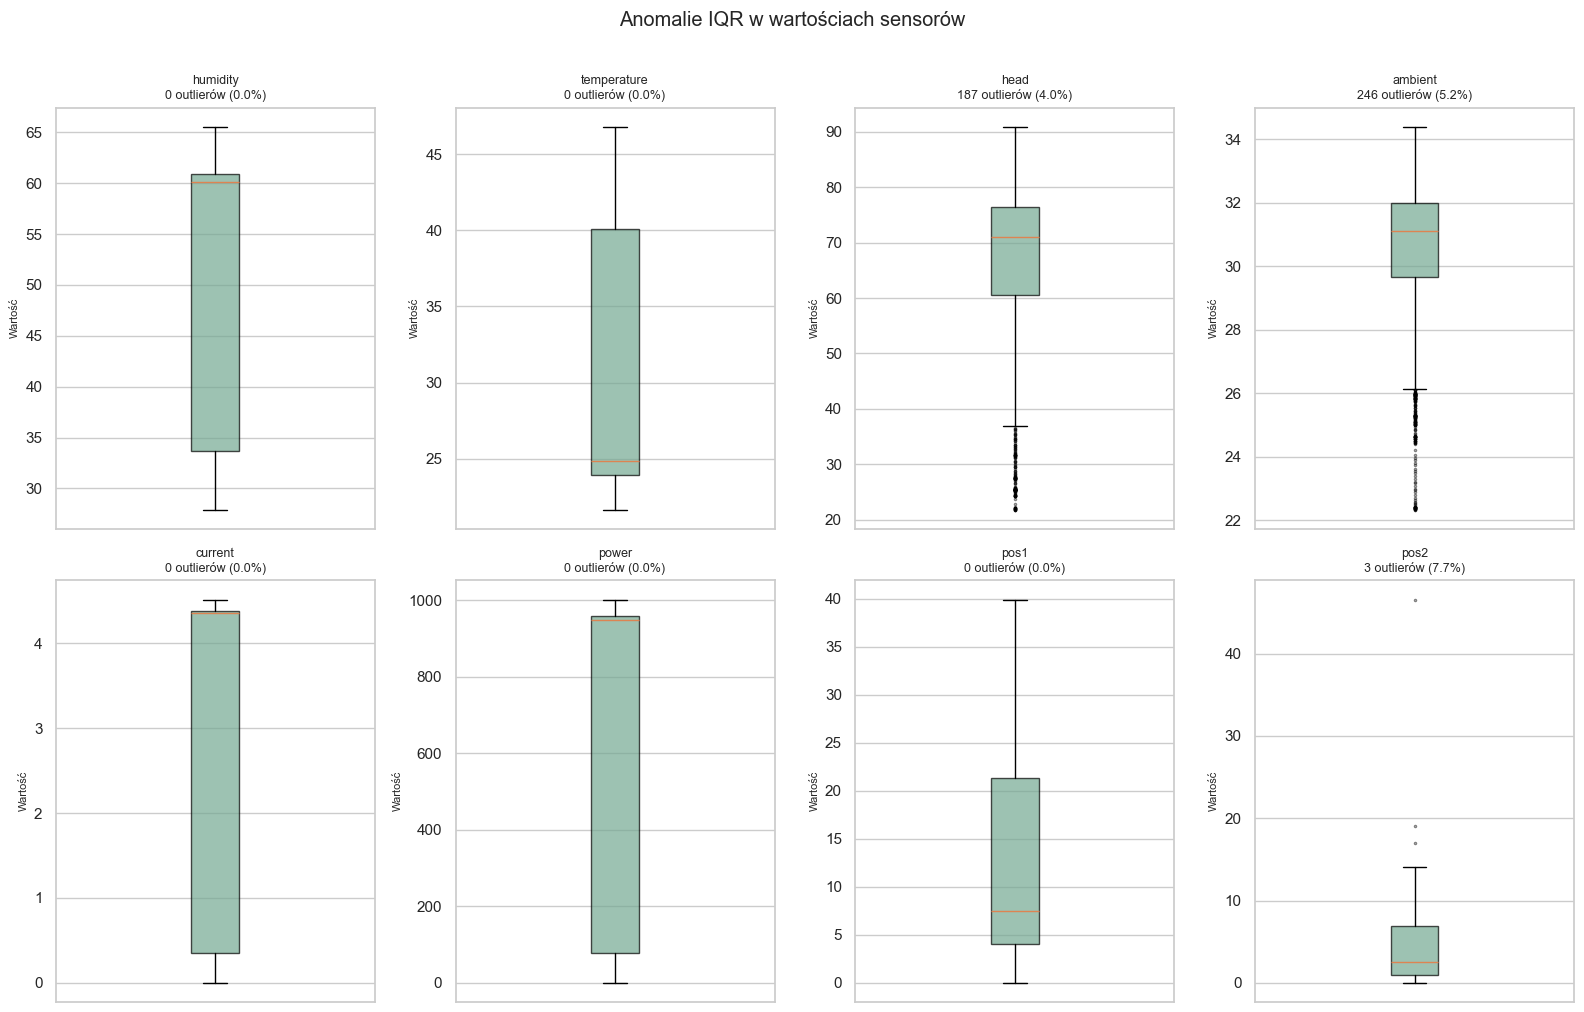


Anomalie case-level (IF na danych sensorowych): 2 / 33

Top 15 anomalnych cases (sensorowo):
                             case_id  sensor_anomaly_score  sensor_anomaly_if
84b674bb-8236-4536-8d52-7044104e4807              0.596043               True
302ac271-ec3b-4cac-a242-d2b14f4b321a              0.570827               True
b057e9c5-f5c7-4ae9-9b10-752663277b34              0.530687              False
ac539644-d15f-47cb-be72-619ec2fb73eb              0.521327              False
f33f7348-d884-4d0d-840a-387a4f7802e9              0.510787              False
3cf1c4b3-779a-4bbc-8160-e76bb908c67b              0.500316              False
d8d20e0b-dfff-4873-8184-720769a0a9a2              0.494314              False
f985c852-de58-4315-8563-c2ad5b0f0315              0.492144              False
c3fb0896-65cb-4956-807c-c3ce7d297171              0.488704              False
9a8fa316-e998-4363-a656-4322df456330              0.486465              False
3f5ed252-8bdd-4e6a-b58e-4a9ff29aa60d            

/opt/miniconda3/envs/base1/lib/python3.12/site-packages/sklearn/utils/extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/miniconda3/envs/base1/lib/python3.12/site-packages/sklearn/utils/extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/miniconda3/envs/base1/lib/python3.12/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


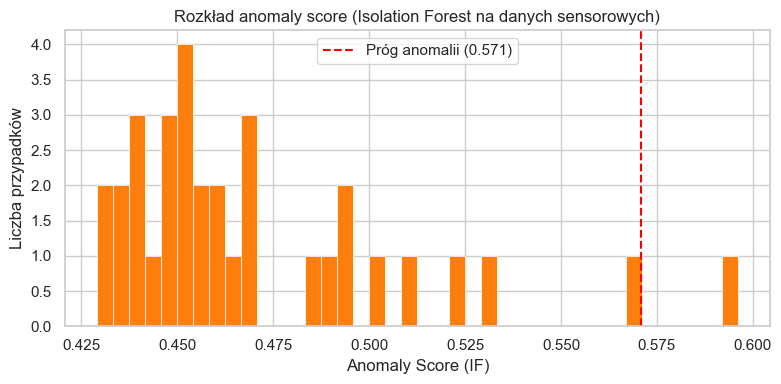


=== Tabela krzyżowa: anomalie log vs sensorowe ===
Anomalia sensorowa (IF)      False  True 
Anomalia log (konsensus ≥2)              
False                           31      1
True                             0      1

Nakładanie się anomalii: 1 cases
Anomalie log: 1, Anomalie sensorowe: 2
% anomalii sensorowych pokrytych przez anomalie log: 50.0%


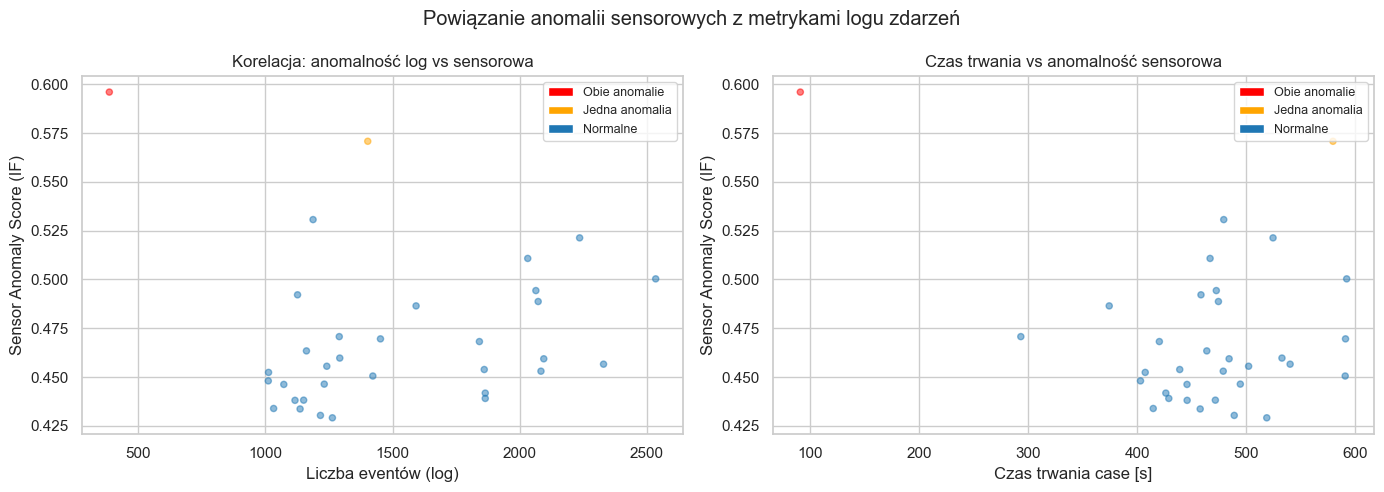

In [37]:
# === 14.1 Anomalie na poziomie punktu pomiarowego (IQR per sensor) ===

sensor_anomaly_summary = {}
df_sensors["is_outlier_iqr"] = False

for sid in top_sensors_for_feat:
    mask_sid = df_sensors["sensor_id"] == sid
    vals = df_sensors.loc[mask_sid, "sensor_value"].dropna()
    if len(vals) < 10:
        continue
    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR_val = Q3 - Q1
    lower = Q1 - 1.5 * IQR_val
    upper = Q3 + 1.5 * IQR_val
    is_out = (df_sensors.loc[mask_sid & df_sensors["sensor_value"].notna(), "sensor_value"] < lower) | \
             (df_sensors.loc[mask_sid & df_sensors["sensor_value"].notna(), "sensor_value"] > upper)
    df_sensors.loc[is_out.index[is_out], "is_outlier_iqr"] = True
    n_out = is_out.sum()
    sensor_anomaly_summary[sid] = {
        "n_records": int(len(vals)),
        "n_outliers": int(n_out),
        "outlier_pct": round(n_out / len(vals) * 100, 2),
        "lower_bound": round(float(lower), 4),
        "upper_bound": round(float(upper), 4),
        "Q1": round(float(Q1), 4),
        "Q3": round(float(Q3), 4),
    }

df_outlier_summary = pd.DataFrame(sensor_anomaly_summary).T.sort_values("outlier_pct", ascending=False)
print("=== Anomalie IQR per sensor ===")
print(df_outlier_summary)

# Boxploty z zaznaczonymi outlierami
n_box = min(8, len(top_sensors_for_feat))
ncols = 4
nrows = (n_box + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for i, sid in enumerate(top_sensors_for_feat[:n_box]):
    ax = axes[i]
    sid_data = df_sensors[df_sensors["sensor_id"] == sid].dropna(subset=["sensor_value"])
    if sid_data.empty:
        ax.set_visible(False)
        continue
    vals = sid_data["sensor_value"]
    bp = ax.boxplot(vals, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#74a892", alpha=0.7),
                    flierprops=dict(marker=".", markersize=3, color="red", alpha=0.5))
    info = sensor_anomaly_summary.get(sid, {})
    n_out = info.get("n_outliers", 0)
    pct = info.get("outlier_pct", 0)
    ax.set_title(f"{sid}\n{n_out} outlierów ({pct:.1f}%)", fontsize=9)
    ax.set_ylabel("Wartość", fontsize=8)
    ax.set_xticks([])

for j in range(n_box, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Anomalie IQR w wartościach sensorów", y=1.01)
plt.tight_layout()
plt.show()

# === 14.2 Anomalie case-level: Isolation Forest na cechach sensorowych ===
if "df_sensor_features" in dir() and not df_sensor_features.empty:
    feat_cols_anom = [c for c in df_sensor_features.columns if c != "case_id"]
    X_sa = df_sensor_features[feat_cols_anom].copy()
    X_sa = X_sa.fillna(X_sa.mean())

    if X_sa.shape[0] > 10 and X_sa.shape[1] > 0:
        from sklearn.preprocessing import StandardScaler
        from sklearn.ensemble import IsolationForest
        scaler_sa = StandardScaler()
        X_sa_scaled = scaler_sa.fit_transform(X_sa)

        iso_s = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
        sensor_if_labels = iso_s.fit_predict(X_sa_scaled)
        sensor_if_scores = -iso_s.score_samples(X_sa_scaled)  # wyższy = bardziej anomalny

        df_sensor_features["sensor_anomaly_if"] = sensor_if_labels == -1
        df_sensor_features["sensor_anomaly_score"] = sensor_if_scores

        n_sa = df_sensor_features["sensor_anomaly_if"].sum()
        print(f"\nAnomalie case-level (IF na danych sensorowych): {n_sa} / {len(df_sensor_features)}")

        # Ranking: top 15 najbardziej anomalnych cases
        top_anom_cases = (
            df_sensor_features.sort_values("sensor_anomaly_score", ascending=False)
            .head(15)[["case_id", "sensor_anomaly_score", "sensor_anomaly_if"]]
        )
        print("\nTop 15 anomalnych cases (sensorowo):")
        print(top_anom_cases.to_string(index=False))

        # Histogram anomaly score
        plt.figure(figsize=(8, 4))
        plt.hist(sensor_if_scores, bins=40, color="#ff7f0e", edgecolor="white", linewidth=0.5)
        threshold = sensor_if_scores[sensor_if_labels == -1].min()
        plt.axvline(threshold, color="red", linestyle="--", label=f"Próg anomalii ({threshold:.3f})")
        plt.xlabel("Anomaly Score (IF)")
        plt.ylabel("Liczba przypadków")
        plt.title("Rozkład anomaly score (Isolation Forest na danych sensorowych)")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # === 14.3 Powiązanie z anomaliami z logu zdarzeń ===
        if "anomaly_consensus" in case_stats.columns:
            merged_anom = case_stats[["case_id", "anomaly_consensus", "iqr_outlier", "iso_outlier", "lof_outlier"]].merge(
                df_sensor_features[["case_id", "sensor_anomaly_if", "sensor_anomaly_score"]],
                on="case_id",
                how="inner"
            )

            # Tabela krzyżowa
            ct = pd.crosstab(
                merged_anom["anomaly_consensus"],
                merged_anom["sensor_anomaly_if"],
                rownames=["Anomalia log (konsensus ≥2)"],
                colnames=["Anomalia sensorowa (IF)"]
            )
            print("\n=== Tabela krzyżowa: anomalie log vs sensorowe ===")
            print(ct)

            overlap = (merged_anom["anomaly_consensus"] & merged_anom["sensor_anomaly_if"]).sum()
            total_anom_log = merged_anom["anomaly_consensus"].sum()
            total_anom_sens = merged_anom["sensor_anomaly_if"].sum()
            pct_overlap = overlap / max(total_anom_sens, 1) * 100
            print(f"\nNakładanie się anomalii: {overlap} cases")
            print(f"Anomalie log: {total_anom_log}, Anomalie sensorowe: {total_anom_sens}")
            print(f"% anomalii sensorowych pokrytych przez anomalie log: {pct_overlap:.1f}%")

            # Scatter: anomaly score sensory vs n_events (z logu)
            scatter_merged = merged_anom.merge(
                case_stats[["case_id", "n_events", "duration_sec"]],
                on="case_id", how="left"
            )
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            colors = scatter_merged.apply(
                lambda r: "red" if r["anomaly_consensus"] and r["sensor_anomaly_if"]
                else ("orange" if r["anomaly_consensus"] or r["sensor_anomaly_if"] else "#1f77b4"),
                axis=1
            )
            axes[0].scatter(scatter_merged["n_events"], scatter_merged["sensor_anomaly_score"],
                           c=colors, alpha=0.5, s=20)
            axes[0].set_xlabel("Liczba eventów (log)")
            axes[0].set_ylabel("Sensor Anomaly Score (IF)")
            axes[0].set_title("Korelacja: anomalność log vs sensorowa")
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor="red", label="Obie anomalie"),
                Patch(facecolor="orange", label="Jedna anomalia"),
                Patch(facecolor="#1f77b4", label="Normalne"),
            ]
            axes[0].legend(handles=legend_elements, fontsize=9)

            axes[1].scatter(scatter_merged["duration_sec"], scatter_merged["sensor_anomaly_score"],
                           c=colors, alpha=0.5, s=20)
            axes[1].set_xlabel("Czas trwania case [s]")
            axes[1].set_ylabel("Sensor Anomaly Score (IF)")
            axes[1].set_title("Czas trwania vs anomalność sensorowa")
            axes[1].legend(handles=legend_elements, fontsize=9)

            plt.suptitle("Powiązanie anomalii sensorowych z metrykami logu zdarzeń")
            plt.tight_layout()
            plt.show()
else:
    print("Brak df_sensor_features. Uruchom najpierw sekcję 13.")

## 16. Podsumowanie Milestone 2

### Analiza logu zdarzeń

**Czyszczenie i normalizacja (sekcja 2)**
- Sparsowano timestampy do UTC, znormalizowano endpointy do hostów, usunięto duplikaty
- Zdarzenia bez timestampa odfiltrowane jako nieanalityczne

**Outliery (sekcja 3)**
- IQR i Isolation Forest identyfikują przypadki z ekstremalną liczbą zdarzeń lub czasem trwania
- Outlierzy to głównie procesy nadrzędne (agregujące podprocesy) lub nietypowo długie przebiegi

**Redukcja wymiarowości (sekcja 4)**
- PCA pokazuje ile komponentów wyjaśnia 90% wariancji; t-SNE i UMAP wizualizują naturalne skupiska

**Klasteryzacja (sekcja 5)**
- K-Means (optymalny k wg Silhouette) dzieli cases na grupy o różnym profilu
- DBSCAN identyfikuje punkty szumu – potencjalne anomalie

**Relacje i czas przejść (sekcja 6)**
- Macierz Directly-Follows pokazuje najczęstsze sekwencje aktywności
- Czasy przejść ujawniają, które kroki są najwolniejsze

**Wzorce czasowe (sekcja 7)**
- Aktywność skupiona w określonych godzinach/dniach tygodnia; widoczna ewolucja między batchami

**Warianty procesu (sekcja 8)**
- Efekt Pareto: niewiele wariantów pokrywa większość przypadków; długi ogon rzadkich wariantów

**Anomalie z logu (sekcja 9)**
- Konsensus 3 metod (IQR, IF, LOF) daje najbardziej wiarygodne anomalie
- Rzadkie warianty procesu częściowo pokrywają się z anomaliami numerycznymi

---

### Analiza danych sensorowych (główny wkład Milestone 2)

**Wczytanie sensorów (sekcja 10)**
- Dane z ~11 typów sensorów: `temperature`, `humidity`, `head`, `ambient`, `current`, `power`, `pos1/2/3`, `weight`, `pressures`
- Pliki `*-process.yaml` ze strukturą `stream:datastream` → ~40k+ punktów pomiarowych

**Eksploracja i jakość (sekcja 11)**
- Dominujące sensory: `humidity` i `temperature` (~9 434 pomiarów każdy), następnie `head`, `ambient`, `current`, `power`
- Jakość danych dobra: brakujące timestampy i wartości nienumeryczne poniżej kilku procent
- Boxploty i histogramy ujawniają bimodalne rozkłady (`temperature`, `humidity`) sugerujące dwa tryby pracy maszyny
- Analiza per batch: zmiany średnich wartości sensorów wskazują na zmiany parametrów operacyjnych

**Szeregi czasowe (sekcja 12)**
- Rolling average (24h) ujawnia długoterminowe trendy w temperaturze i wilgotności
- Coefficient of Variation (CV) identyfikuje najbardziej niestabilne sensory (kandydaci do monitorowania)
- Heatmapy sezonowości pokazują, w jakich godzinach maszyna pracuje intensywnie

**Korelacje i PCA (sekcja 13)**
- Macierz korelacji między sensorami: silne powiązania między `temperature` ↔ `ambient`, `current` ↔ `power`
- PCA na cechach sensorowych per case: ładunki wskazują, które sensory dominują w zmienności
- Scatter plots najsilniejszych par korelacji potwierdzają fizyczne zależności systemu

**UMAP i klasteryzacja sensorowa (sekcja 14)**
- UMAP (2D) na zestandaryzowanych cechach sensorowych per case – nieliniowe osadzenie zachowuje lokalne skupiska
- K-Means z doborem k metodą Silhouette dzieli cases sensorowe na grupy o różnym profilu
- DBSCAN na przestrzeni UMAP identyfikuje outliery sensorowe i naturalnie ukształtowane klastry
- Heatmapa profilu klastrów (wartości znormalizowane) ujawnia, które sensory charakteryzują każdą grupę

**Anomalie sensorowe (sekcja 15)**
- IQR per sensor: `weight` i `pos*` mają najwyższy odsetek outlierów (rzadsze sensory = mniej stabilne)
- Isolation Forest na cechach sensorowych case-level: ~5% przypadków z anomalnym profilem sensorowym
- **Powiązanie log ↔ sensory**: tabela krzyżowa i scatter wykazują, że część anomalii z logu zdarzeń koreluje z anomaliami sensorowymi – wspólne anomalie to najbardziej wiarygodne kandydaty do dalszej analizy root-cause
